# Práctico 2 — Análisis Exploratorio y Curación de Datos
## DiploDatos 2026 · Ciencia de Datos Aplicada al Fútbol

**Objetivos de aprendizaje**
- Realizar un EDA riguroso sobre datos de eventos de fútbol
- Detectar y tratar problemas de calidad: valores faltantes, outliers, inconsistencias
- Convertir eventos de Wyscout al formato SPADL (Soccer Player Action Description Language)
- Construir features contextuales y posicionales para modelado
- Entender el sesgo de selección en datos deportivos

**Referencia clave**: Decroos et al. (2019) *Actions Speak Louder than Goals: Valuing Player Actions in Football*

---

### **Entregable 4/9/26**: 
- Notebook con EDA completo
- Reporte de decisiones de curación 
- PPT con donde se muestren los principales hallazgos encontrados en los dos primeros TPs.

---

In [1]:
# ! pip install -r ../requirements.txt

In [2]:
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, normaltest
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import plotly.express as px
import plotly.graph_objects as go
#from scipy.stats import gaussian_kde
from mplsoccer import Pitch, VerticalPitch, FontManager
from mplsoccer.utils import FontManager
import sys
import time
from pathlib import Path
from typing import List, Dict, Callable, Optional, Union
import pyarrow.parquet as pq
from io import BytesIO
from statsmodels.stats.outliers_influence import variance_inflation_factor

# socceraction: librería oficial para SPADL
import socceraction.spadl as spadl
from socceraction.data.wyscout import WyscoutLoader

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Configuración visual
PALETTE = sns.color_palette('Set2')
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)

# -- CONFIGURACION DE RUTAS --
DATA_DIR = Path('../data')
DATASET_DIR = DATA_DIR / 'events'
print(f'Data dir: {DATA_DIR}')
print(f'Dataset dir: {DATASET_DIR}')
print('✓ Librerías importadas correctamente')

Data dir: ../data
Dataset dir: ../data/events
✓ Librerías importadas correctamente


## 1. Carga completa del dataset multliga

En este práctico trabajamos con **todas las ligas** para tener una base más robusta.

In [3]:
#La siguiente celda enumera las competiciones que se incluirán en el conjunto de datos.
#Descomente las competiciones que desee incluir en su conjunto de datos.

competitions = [
    'England',
# 'France',
#    'Germany',
    'Italy',
    'Spain',
#    'European Championship',
#  'World Cup'
]

### 1.1 Lectura Optimizada de eventos desde archivos Parquet

In [4]:
def load_events_parquet(
    parquet_path: Path, 
    columns: Optional[List[str]] = None, 
    filters: Optional[List[tuple]] = None
) -> pd.DataFrame:
    """
    Carga eventos desde un archivo Parquet de forma optimizada.
    
    Parametros
    ----------
    parquet_path : Path al archivo .parquet.
    columns : Subconjunto de columnas a leer (None = todas).
    filters : Lista de tuplas para filtrar antes de cargar.
              Ejemplo: [('eventName', '==', 'Shot')]
    """
    print(f'[INFO] Cargando {parquet_path.name}...')
    t0 = time.time()
    
    # Leer con pyarrow + pandas para mejor rendimiento y control de tipos
    df = pd.read_parquet(
        parquet_path, 
        columns=columns, 
        filters=filters, 
        engine='pyarrow'
    )
    
    elapsed = time.time() - t0
    print(f'[INFO] Cargado en {elapsed:.2f}s | Filas: {len(df):,} | Columnas: {len(df.columns)}')
    return df


In [5]:
dfs=[]
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_events = f'events_{competition_name}.parquet'
    print(f"file: {file_events}")
    FILE_PATH=DATASET_DIR / file_events
    print(f"file path: {FILE_PATH}")
    #json_events = read_json_file(file_events)
    data = load_events_parquet(
                            FILE_PATH,
                            columns= ['eventId', 'subEventName', 'tags', 'playerId', 'positions', 'matchId', 'eventName', 'teamId', 'matchPeriod', 'eventSec', 'subEventId', 'id']
                        )
    #df_all = pd.DataFrame(data)
    data['league'] = competition
    dfs.append(data)#df_all)
    print(f'  {competition}: {len(data):>8,} eventos')
    del data
# ignore_index=True es imprescindible: cada parquet trae su propio indice 0..n, y sin
# esto quedan 1.271.809 etiquetas duplicadas. Un drop(index=...) posterior borraria
# una fila por liga en vez de una sola (ver Decision 5).
df_all = pd.concat(dfs, ignore_index=True)
del dfs
print(f'\nTotal: {len(df_all):,} eventos | {df_all["league"].nunique()} ligas')

file: events_England.parquet
file path: ../data/events/events_England.parquet
[INFO] Cargando events_England.parquet...


[INFO] Cargado en 0.91s | Filas: 643,150 | Columnas: 12
  England:  643,150 eventos
file: events_Italy.parquet
file path: ../data/events/events_Italy.parquet
[INFO] Cargando events_Italy.parquet...


[INFO] Cargado en 0.63s | Filas: 647,372 | Columnas: 12
  Italy:  647,372 eventos
file: events_Spain.parquet
file path: ../data/events/events_Spain.parquet
[INFO] Cargando events_Spain.parquet...


[INFO] Cargado en 0.55s | Filas: 628,659 | Columnas: 12
  Spain:  628,659 eventos



Total: 1,919,181 eventos | 3 ligas


### 1.2 Lectura de archivos de partidos

In [6]:

def read_json_file(filename):
    with open(filename, 'rb') as json_file:
        return BytesIO(json_file.read()).getvalue().decode('unicode_escape')

def load_json(path: str) -> pd.DataFrame:
    print(path)
    data = pd.read_json(str(path))
    #data=read_json_file(path)
    return data#pd.read_json(data)


In [7]:
dfs_matches = []
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_matches = f'matches/matches_{competition_name}.json'
    #print(f"file: {file_matches}")
    FILE_PATH=DATA_DIR / file_matches
    print(f"file path: {FILE_PATH}")
    #json_matches = read_json_file(FILE_PATH)
    data = load_json(FILE_PATH)#pd.read_json(json_matches)
    dfs_matches.append(data)
    del data
df_matches = pd.concat(dfs_matches)
del dfs_matches
df_matches.head(3)

file path: ../data/matches/matches_England.json
../data/matches/matches_England.json
file path: ../data/matches/matches_Italy.json
../data/matches/matches_Italy.json
file path: ../data/matches/matches_Spain.json
../data/matches/matches_Spain.json


,status,roundId,gameweek,teamsData,seasonId,dateutc,winner,venue,wyId,label,date,referees,duration,competitionId
0,Played,4405654,38,"{'1646': {'scoreET': 0, 'coachId': 8880, 'side...",181150,2018-05-13 14:00:00,1659,Turf Moor,2500089,"Burnley - AFC Bournemouth, 1 - 2","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 385705, 'role': 'referee'}, {'r...",Regular,364
1,Played,4405654,38,"{'1628': {'scoreET': 0, 'coachId': 8357, 'side...",181150,2018-05-13 14:00:00,1628,Selhurst Park,2500090,"Crystal Palace - West Bromwich Albion, 2 - 0","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 381851, 'role': 'referee'}, {'r...",Regular,364
2,Played,4405654,38,"{'1609': {'scoreET': 0, 'coachId': 7845, 'side...",181150,2018-05-13 14:00:00,1609,The John Smith's Stadium,2500091,"Huddersfield Town - Arsenal, 0 - 1","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 384965, 'role': 'referee'}, {'r...",Regular,364


### 1.3 Lectura de archivos de jugadores y equipos

In [8]:
# Carga de metadata de equipos
df_teams = load_json(DATA_DIR / 'teams.json')
df_teams

../data/teams.json


,city,name,wyId,officialName,area,type
0,Newcastle upon Tyne,Newcastle United,1613,Newcastle United FC,"{'name': 'England', 'id': '0', 'alpha3code': '...",club
1,Vigo,Celta de Vigo,692,Real Club Celta de Vigo,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
2,Barcelona,Espanyol,691,Reial Club Deportiu Espanyol,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
3,Vitoria-Gasteiz,Deportivo Alav\u00e9s,696,Deportivo Alav\u00e9s,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
4,Valencia,Levante,695,Levante UD,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
...,...,...,...,...,...,...
137,Las Rozas,Spain,1598,Spain,"{'name': 'Spain', 'id': 724, 'alpha3code': 'ES...",national
138,Beograd,Serbia,17322,Serbia,"{'name': 'Serbia', 'id': 688, 'alpha3code': 'S...",national
139,Bern,Switzerland,6697,Switzerland,"{'name': 'Switzerland', 'id': 756, 'alpha3code...",national
140,Warszawa,Poland,13869,Poland,"{'name': 'Poland', 'id': 616, 'alpha3code': 'P...",national


In [9]:
# Carga de metadata de jugadores
df_players = load_json(DATA_DIR / 'players.json')
df_players.head(3)

../data/players.json


,passportArea,weight,firstName,middleName,lastName,currentTeamId,birthDate,height,role,birthArea,wyId,foot,shortName,currentNationalTeamId
0,"{'name': 'Turkey', 'id': '792', 'alpha3code': ...",78,Harun,,Tekin,4502,1989-06-17,187,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Turkey', 'id': '792', 'alpha3code': ...",32777,right,H. Tekin,4687
1,"{'name': 'Senegal', 'id': '686', 'alpha3code':...",73,Malang,,Sarr,3775,1999-01-23,182,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'France', 'id': '250', 'alpha3code': ...",393228,left,M. Sarr,4423
2,"{'name': 'France', 'id': '250', 'alpha3code': ...",72,Over,,Mandanda,3772,1998-10-26,176,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'France', 'id': '250', 'alpha3code': ...",393230,,O. Mandanda,null


## 2. EDA — Análisis Exploratorio de Datos

### 2.1 Estructura y tipos de datos

In [10]:
print('=== INFO GENERAL DEL DATASET ===')
print(f'Shape: {df_all.shape}')
print(f'Memoria: {df_all.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Tipos de datos:')
print(df_all.dtypes)

=== INFO GENERAL DEL DATASET ===
Shape: (1919181, 13)
Memoria: 1076.6 MB

Tipos de datos:
eventId           int64
subEventName     object
tags             object
playerId          int64
positions        object
matchId           int64
eventName        object
teamId            int64
matchPeriod      object
eventSec        float64
subEventId       object
id                int64
league           object
dtype: object


### 2.2 Análisis de valores faltantes

In [11]:
def analyze_missing(df):
    """Genera reporte completo de valores faltantes."""
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct,
        'dtype': df.dtypes
    }).sort_values('missing_pct', ascending=False)
    return report[report['missing_count'] > 0]

missing_report = analyze_missing(df_all)
print('Columnas con valores faltantes:')
print(missing_report.to_string())

Columnas con valores faltantes:
Empty DataFrame
Columns: [missing_count, missing_pct, dtype]
Index: []


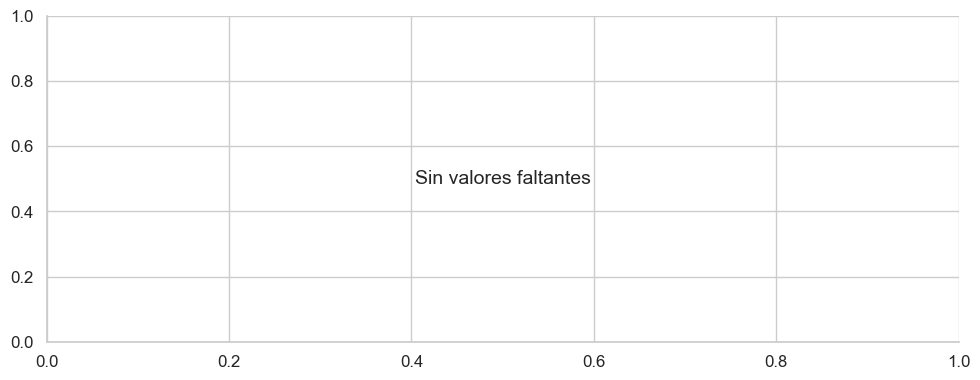

In [12]:
# Visualización del patrón de missings
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing_report[missing_report['missing_pct'] > 0].index
if len(cols_with_missing) > 0:
    missing_report[missing_report['missing_pct'] > 0]['missing_pct'].sort_values().plot(
        kind='barh', ax=ax, color='#378ADD'
    )
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Análisis de valores faltantes por columna')
    ax.axvline(x=5, color='orange', linestyle='--', label='Umbral 5%')
    ax.axvline(x=20, color='red', linestyle='--', label='Umbral 20%')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Sin valores faltantes', ha='center', va='center', fontsize=14)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 2.3 Extracción y análisis de coordenadas.

In [13]:
def parse_positions(pos_list):
    """Extrae coordenadas x,y del campo (0-100) desde el campo 'positions'."""
    if isinstance(pos_list, list) and len(pos_list) >= 1:
        return pos_list[0].get('x', np.nan), pos_list[0].get('y', np.nan)
    return np.nan, np.nan

def parse_end_positions(pos_list):
    """Extrae posición final de la acción."""
    if isinstance(pos_list, list) and len(pos_list) >= 2:
        return pos_list[1].get('x', np.nan), pos_list[1].get('y', np.nan)
    return np.nan, np.nan

def parse_tags(tag_list):
    """Extrae lista de IDs de tags."""
    if isinstance(tag_list.tolist(), list):
        return [t.get('id') for t in tag_list.tolist()]
    return []


In [14]:

# Aplicamos parseo vectorizado
df_all[['x', 'y']] = df_all['positions'].apply(
    lambda p: pd.Series(parse_positions(p.tolist()))
)
df_all[['end_x', 'end_y']] = df_all['positions'].apply(
    lambda p: pd.Series(parse_end_positions(p.tolist()))
)
df_all['tag_ids'] = df_all['tags'].apply(parse_tags)


#### Auditoría de coordenadas

In [15]:
print('=== AUDITORÍA DE COORDENADAS ===')
print(f'Eventos con x válido: {df_all["x"].notna().sum():,} ({df_all["x"].notna().mean():.1%})')
print(f'Eventos con y válido: {df_all["y"].notna().sum():,} ({df_all["y"].notna().mean():.1%})')
print(f'Rango x: [{df_all["x"].min():.1f}, {df_all["x"].max():.1f}]')
print(f'Rango y: [{df_all["y"].min():.1f}, {df_all["y"].max():.1f}]')

# Eventos fuera de rango (0-100)
out_of_bounds = df_all[
    (df_all['x'].notna()) & 
    ((df_all['x'] < 0) | (df_all['x'] > 100) | (df_all['y'] < 0) | (df_all['y'] > 100))
]
print(f'\nEventos con coordenadas fuera de rango: {len(out_of_bounds)} ({len(out_of_bounds)/len(df_all):.2%})')

=== AUDITORÍA DE COORDENADAS ===
Eventos con x válido: 1,919,181 (100.0%)
Eventos con y válido: 1,919,181 (100.0%)
Rango x: [-1.0, 100.0]
Rango y: [0.0, 100.0]

Eventos con coordenadas fuera de rango: 1 (0.00%)


In [16]:
out_of_bounds

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,league,x,y,end_x,end_y,tag_ids
783993,7,Touch,[],166534,"[{'x': -1, 'y': 47}, {'x': 69, 'y': 12}]",2576042,Others on the ball,3162,2H,2753.1903,72,198907641,Italy,-1,47,69.0000,12.0000,[]


##### Se detecta un único caso en la liga Italiana, y siendo un evento "Others on the ball" y "Touch" en subEventName, en el segundo tiempo (45.89 minutos), la decisión es eliminar el registro. Documentación de la decisión:

Problema: coordenada x=-1 fuera del rango válido (0-100).
Registros afectados: 1 de 1.919.181 (0.00005%).
Decisión de curación: eliminar. Dado que es "Others on the ball" (acción sin relevancia táctica clara).
Alternativa considerada: imputar con la mediana de x para ese tipo de evento, pero con un solo caso no vale la pena.

In [17]:
# Eliminamos el registro con coordenada fuera de rango
n_antes = len(df_all)
df_all = df_all.drop(index=out_of_bounds.index)
df_all = df_all.reset_index(drop=True)

# Se reporta el delta real, no len(out_of_bounds): si el indice tuviera etiquetas
# repetidas, drop() borraria mas filas de las esperadas y el conteo lo delataria.
n_eliminados = n_antes - len(df_all)
print(f'Registros identificados fuera de rango: {len(out_of_bounds)}')
print(f'Registros efectivamente eliminados: {n_eliminados}')
assert n_eliminados == len(out_of_bounds), 'drop() elimino mas filas de las esperadas'
print(f'Nuevo tamano de df_all: {len(df_all):,}')


Registros identificados fuera de rango: 1
Registros efectivamente eliminados: 1
Nuevo tamano de df_all: 1,919,180


#### Distribución espacial de los eventos — heatmap 2D

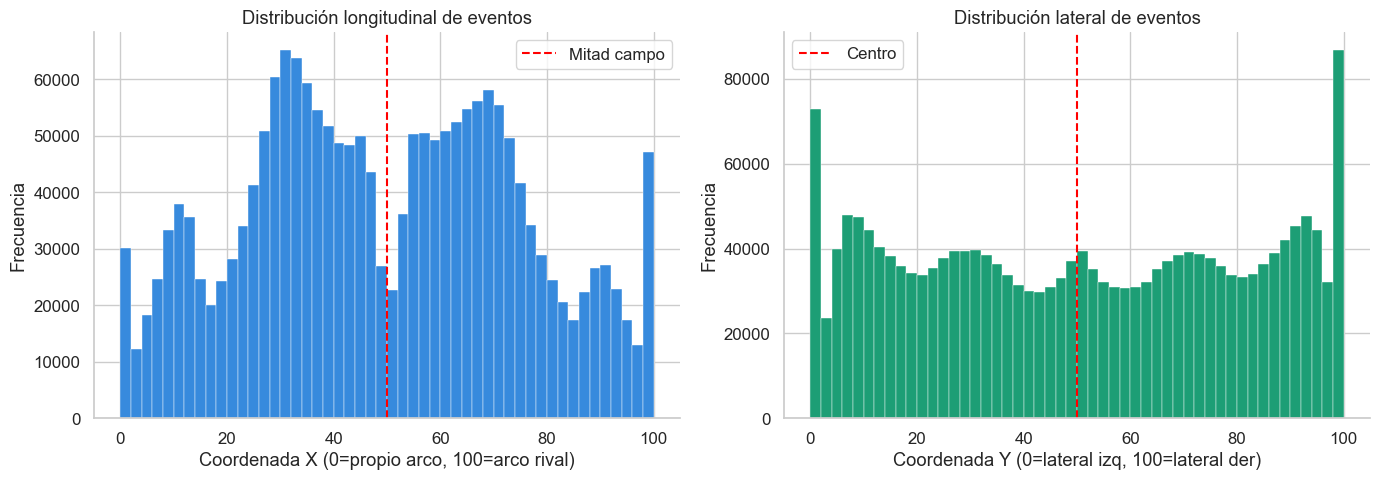

In [18]:

df_valid = df_all.dropna(subset=['x','y'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución x
axes[0].hist(df_valid['x'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Coordenada X (0=propio arco, 100=arco rival)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución longitudinal de eventos')
axes[0].axvline(50, color='red', linestyle='--', label='Mitad campo')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Distribución y
axes[1].hist(df_valid['y'], bins=50, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Coordenada Y (0=lateral izq, 100=lateral der)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución lateral de eventos')
axes[1].axvline(50, color='red', linestyle='--', label='Centro')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## Análisis parciales de los resultados de distribución de eventos. 

Existen algunos resultados coherentes: los picos en X entre 30-40; y entre 55-75 aproximadamente son consistentes con las zonas de gestación en la mitad propia/presión del rival y con la fase de ataque y defensa del rival. El mediocampo es una zona de transición. Si llama un poco más la atención las colas cargadas en X=0 y X=100, que si bien pueden ser consistentes con saques de arco, corners, goles, vale la pena examinar más.
Si es más llamativa la concentración en Y=0 e Y=100, que si bien pueden representar saques de banda y corners, la concentración es notable y conviene analizarla. 

### ¿Son placeholders sistemáticos de Wyscout para eventos sin coordenada precisa?

In [19]:
# Ver los eventos en cada borde

for val, eje in [(0, 'x'), (100, 'x'), (0, 'y'), (100, 'y')]:
    mask = df_all[eje] == val
    print(f"\n=== {eje}={val} — {mask.sum():,} eventos ({mask.mean():.1%}) ===")
    print(df_all[mask]['eventName'].value_counts().head(10))


=== x=0 — 26,522 eventos (1.4%) ===
eventName
Interruption               11729
Free Kick                   8423
Save attempt                4615
Goalkeeper leaving line     1608
Others on the ball            73
Pass                          49
Duel                          24
Foul                           1
Name: count, dtype: int64

=== x=100 — 39,941 eventos (2.1%) ===
eventName
Free Kick                  21720
Interruption               10350
Save attempt                5705
Goalkeeper leaving line     2026
Pass                          93
Duel                          23
Others on the ball            12
Foul                           6
Shot                           4
Offside                        2
Name: count, dtype: int64

=== y=0 — 69,295 eventos (3.6%) ===
eventName
Free Kick                  37373
Interruption               24977
Save attempt                4615
Goalkeeper leaving line     1608
Pass                         533
Others on the ball            98
Duel         

In [20]:
# Ver si hay diferencias en la concentración de eventos en los bordes, por ligas

for liga in df_all['league'].unique():
    sub = df_all[df_all['league'] == liga]
    borde_y = ((sub['y'] == 0) | (sub['y'] == 100)).mean()
    borde_x = ((sub['x'] == 0) | (sub['x'] == 100)).mean()
    print(f"{liga}: borde_y={borde_y:.1%}, borde_x={borde_x:.1%}")

England: borde_y=7.6%, borde_x=3.4%
Italy: borde_y=7.4%, borde_x=3.5%
Spain: borde_y=7.4%, borde_x=3.4%


#### Conclusiones 

Los 2 ejercicios realizados son consistentes y coherentes: 

1. Los eventos en los bordes son interrupciones (salidas del campo), freekicks que concentra saques laterales, corners y tiros libres propiamente dichos) o salvadas del arquero entre los más frecuentes.
2. Comparación entre ligas: la distribución es identica, por lo que no parecieran placeholders particulares según la liga.

#### Conclusión general: No se trata de eventos anómalos que deban eliminarse o imputarse. Decisión final: conservación de eventos en coordenadas extremas (x=0, x=100, y=0, y=100).

### 2.4 Detección de outliers y anomalías en los datos
En eventos de fútbol, los valores atípicos suelen originarse por:
1. **Errores de registro o medición:** Coordenadas fuera de escala o valores temporales anómalos (detectables con métodos estadísticos como IQR y Z-Score).
2. **Partidos incompletos o truncados:** Partidos con una cantidad inusualmente baja o excesiva de eventos registrados respecto a la media.
3. **Casos reales extremos (outliers válidos):** Jugadas excepcionales que no deben eliminarse porque forman parte del juego real.

In [21]:
def detect_outliers_iqr(series: pd.Series, factor: float = 1.5) -> pd.Series:
    """Detecta outliers usando el criterio IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Detecta outliers usando Z-score nativo de pandas."""
    mean = series.mean()
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(False, index=series.index)
    z = ((series - mean) / std).abs()
    return (z > threshold).fillna(False)


In [22]:
# Si ya extrajiste x e y de 'positions':
for col in ['x', 'y']:
    if col in df_all.columns:
        series = df_all[col].dropna()
        iqr_outliers = detect_outliers_iqr(series)
        z_outliers   = detect_outliers_zscore(series)
        print(f'{col}: IQR outliers={iqr_outliers.sum():,} | Z-score outliers={z_outliers.sum():,}')

print('\n=== ANÁLISIS DE PERÍODOS ===')
if 'matchPeriod' in df_all.columns and 'eventSec' in df_all.columns:
    print(df_all.groupby('matchPeriod')['eventSec'].describe())


x: IQR outliers=0 | Z-score outliers=0
y: IQR outliers=0 | Z-score outliers=0

=== ANÁLISIS DE PERÍODOS ===
                  count      mean      std    min      25%       50%  \
matchPeriod                                                            
1H          961337.0000 1360.6149 812.5093 0.0355 650.8960 1346.7117   
2H          957843.0000 1434.5367 859.6432 0.0000 681.5883 1420.7891   

                  75%       max  
matchPeriod                      
1H          2062.5143 3302.2827  
2H          2177.6324 3476.7790  


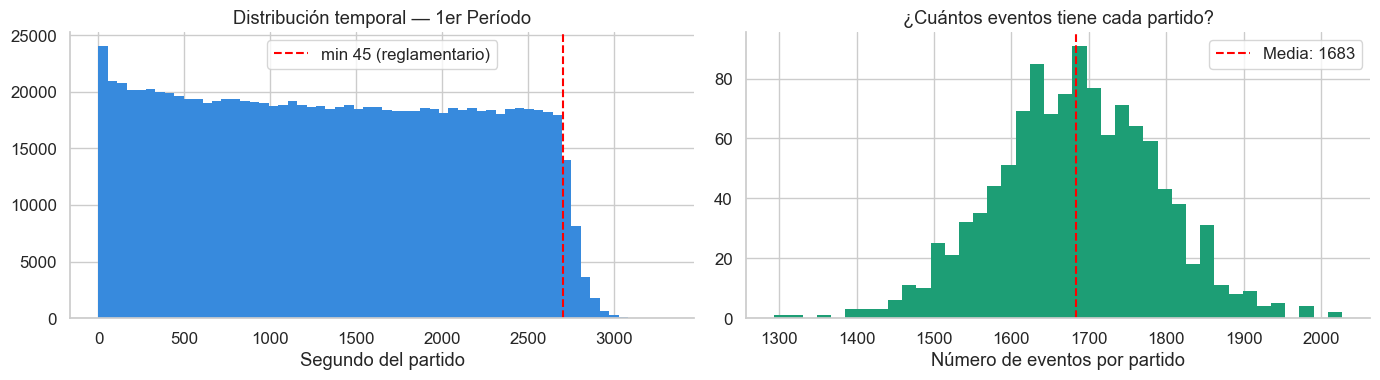

Partidos potencialmente problemáticos: 24


In [23]:
# Análisis de tiempos de eventos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución de segundos en el primer período
p1 = df_all[df_all['matchPeriod'] == '1H']['eventSec'].clip(0, 6000)
axes[0].hist(p1, bins=60, color='#378ADD', edgecolor='none')
axes[0].set_xlabel('Segundo del partido')
axes[0].set_title('Distribución temporal — 1er Período')
axes[0].axvline(45*60, color='red', linestyle='--', label='min 45 (reglamentario)')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Número de eventos por partido — distribución
events_per_match = df_all.groupby('matchId').size()
axes[1].hist(events_per_match, bins=40, color='#1D9E75', edgecolor='none')
axes[1].set_xlabel('Número de eventos por partido')
axes[1].set_title('¿Cuántos eventos tiene cada partido?')
axes[1].axvline(events_per_match.mean(), color='red', linestyle='--', 
                label=f'Media: {events_per_match.mean():.0f}')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# Partidos con muy pocos o muchos eventos (posibles problemas de datos)
q01 = events_per_match.quantile(0.01)
q99 = events_per_match.quantile(0.99)
problematic = events_per_match[(events_per_match < q01) | (events_per_match > q99)]
print(f'Partidos potencialmente problemáticos: {len(problematic)}')

### Hallazgo — Tiempo de descuento en eventSec

**Observación:** `eventSec` puede superar los 2700s (45 min × 60s) en el 1H y 
los 2700s en el 2H. Esto refleja el tiempo de descuento, que Wyscout registra 
como continuación del período (no como período separado).

**Evidencia:**
- 1H: max eventSec = 3302s (~55 min reales)
- 2H: max eventSec = 3476s (~58 min reales)

**Impacto:** no afecta al análisis de volumen ni al pipeline SPADL. Sí afecta 
a cualquier análisis temporal que asuma que 1H ⊂ [0, 2700s] o que use ventanas 
de minuto fijo (ej. Ejercicio 2 — intensidad de eventos por minuto).

**Decisión:** cuando se realice el Ejercicio 2, convertir `eventSec` 
a minuto de partido continuo antes de graficar:

```python
# Conversión a minuto continuo (pendiente para Ejercicio 2)
df_all['minute'] = df_all.apply(
    lambda r: r['eventSec'] / 60 if r['matchPeriod'] == '1H'
              else 45 + r['eventSec'] / 60,
    axis=1
)
```

Esto produce un eje de 0 a ~103 min que incluye el tiempo de descuento 
de forma natural y legible, sin truncar ni perder eventos reales.

### 2.5 Análisis de sesgo en los datos

Los datos deportivos tienen sesgos importantes que debemos documentar:
- Sesgo de equipo: los equipos más populares tienen más cobertura
- Sesgo de posición: los jugadores ofensivos tienen más eventos registrados
- Sesgo de resultado: se registran más eventos cerca de los goles

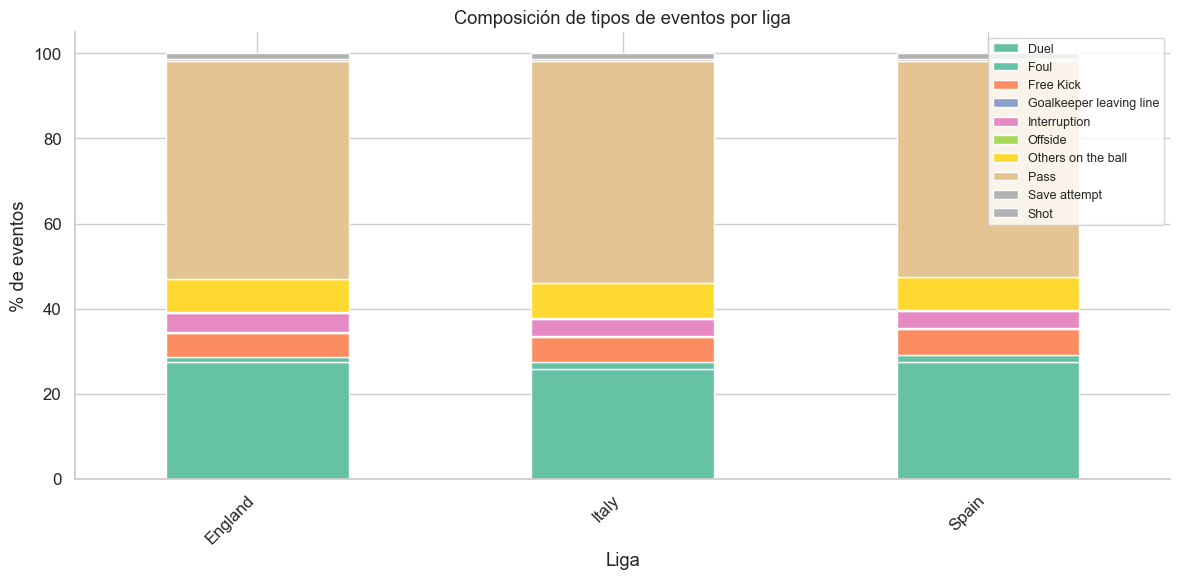


¿Son comparables los datos entre ligas? ¿Hay diferencias en la anotación?


In [24]:
# Distribución de eventos por tipo — ¿hay sesgo hacia eventos ofensivos?
event_dist = df_all.groupby(['league', 'eventName']).size().unstack(fill_value=0)
event_dist_pct = event_dist.div(event_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
event_dist_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_xlabel('Liga')
ax.set_ylabel('% de eventos')
ax.set_title('Composición de tipos de eventos por liga')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n¿Son comparables los datos entre ligas? ¿Hay diferencias en la anotación?')

#### Conclusiones parciales 

¿Son comparables los datos entre ligas? 
El gráfico previo permite apreciar que no existen sesgos de registros en las 3 ligas seleccionadas, y a priori las tres fueron capturadas con los mismos criterios y la misma metodología de Wyscout.

## 3. Conversión a SPADL

SPADL (Soccer Player Action Description Language) es el formato estándar propuesto por
Decroos et al. (2019). Representa cada acción como un vector con:
- `game_id`, `period_id`, `time_seconds`: identificación temporal
- `team_id`, `player_id`: actores
- `start_x`, `start_y`, `end_x`, `end_y`: posiciones
- `action_type_id`: tipo de acción (18 tipos estandarizados)
- `bodypart_id`: parte del cuerpo usada
- `result_id`: resultado (exitoso/fallido/gol/etc)

In [25]:
# 1. Extraer los IDs únicos que realmente existen en tus eventos filtrados
# (Asegúrate de que los nombres de las columnas coincidan con los de tu df_all)
equipos_validos = df_all['teamId'].unique()
jugadores_validos = df_all['playerId'].unique()

# Opcional: Eliminar el ID '0' si existe (Wyscout usa 0 para eventos sin un jugador/equipo específico)
jugadores_validos = [pid for pid in jugadores_validos if pid != 0]

# 2. Filtrar df_teams y df_players
# (En los datos crudos de Wyscout, la columna de ID para equipos y jugadores suele ser 'wyId')
df_teams_filtrado = df_teams[df_teams['wyId'].isin(equipos_validos)]
df_players_filtrado = df_players[df_players['wyId'].isin(jugadores_validos)]

# 3. Agrupar los eventos por partido (como hicimos antes)
# (Revisa si en tu df_all la columna es 'matchId' o 'match_id')
#
# IMPORTANTE (ver Decision 1): df_all arrastra las columnas 'x','y','end_x','end_y'
# creadas en el EDA (seccion 2.3). Los nombres 'end_x'/'end_y' colisionan con los que
# genera make_new_positions() dentro de wyscout.py: el pd.merge las renombra a
# end_x_x / end_x_y y el pipeline se queda sin columna 'end_x'. La primera funcion
# que le asigna un valor (create_shot_coordinates) la crea de cero llena de NaN, y el
# destino de pases, tackles y take_ons se pierde (87% de NaN en end_x).
# Se sueltan antes de convertir: el EDA las conserva, la conversion recibe el df limpio.
COLS_EDA = ['x', 'y', 'end_x', 'end_y']

events_dict = {
    match_id: df.drop(columns=[c for c in COLS_EDA if c in df.columns])
    for match_id, df in df_all.groupby('matchId')
}

# 4. Armar el diccionario con los datos ya limpios y filtrados
datos_wyscout = {
    "matches": df_matches,  # Este ya lo tenías filtrado
    "players": df_players_filtrado, # <-- ¡Usamos el filtrado!
    "teams": df_teams_filtrado,     # <-- ¡Usamos el filtrado!
    "events": events_dict
}


In [26]:
from socceraction.spadl.config import actiontypes, bodyparts, results

In [27]:
from wyscout import (
    convert_games, 
    convert_players, 
    convert_teams, 
    get_player_games, 
    convert_actions
)

In [28]:
import tqdm

def convert_to_spadl_memory(wyscout_data, actiontypes, bodyparts, results):
    """
    Convierte datos de Wyscout a SPADL usando DataFrames en memoria.
    
    Parámetros:
    wyscout_data: dict que contiene las claves 'matches', 'players', 'teams' 
                  y un diccionario de 'events' agrupado por ID de partido.
    """
    # Diccionario que guardará todos nuestros DataFrames convertidos
    spadl_data = {}

    print("...Inserting actiontypes, bodyparts, results")
    spadl_data["actiontypes"] = pd.DataFrame(
        list(enumerate(actiontypes)), columns=["type_id", "type_name"]
    )
    spadl_data["bodyparts"] = pd.DataFrame(
        list(enumerate(bodyparts)), columns=["bodypart_id", "bodypart_name"]
    )
    spadl_data["results"] = pd.DataFrame(
        list(enumerate(results)), columns=["result_id", "result_name"]
    )

    print("...Converting matches, players, teams")
    # Nota: Asegúrate de tener importadas/definidas convert_games, convert_players, convert_teams
    matches = wyscout_data["matches"]
    games = convert_games(matches)
    
    spadl_data["games"] = games
    spadl_data["players"] = convert_players(wyscout_data["players"])
    spadl_data["teams"] = convert_teams(wyscout_data["teams"])

    print("...Generating player_games")
    player_games = []
    for match in tqdm.tqdm(list(matches.itertuples()), unit="game"):
        # Asume que guardaste los eventos en un diccionario donde la clave es el ID del partido
        events = wyscout_data["events"][match.wyId] 
        
        pg = get_player_games(match, events)
        player_games.append(pg)
        
    spadl_data["player_games"] = pd.concat(player_games)

    print("...Converting events to actions")
    spadl_data["actions"] = {} # Sub-diccionario para las acciones de cada partido
    
    for game in tqdm.tqdm(list(games.itertuples()), unit="game"):
        events = wyscout_data["events"][game.game_id]
        actions = convert_actions(events, game.home_team_id)
        
        # Guardamos las acciones en memoria, usando el ID del partido como clave
        spadl_data["actions"][game.game_id] = actions
        
    return spadl_data

In [29]:

# 5. Ejecutar la función
datos_spadl = convert_to_spadl_memory(datos_wyscout, actiontypes, bodyparts, results)

...Inserting actiontypes, bodyparts, results
...Converting matches, players, teams
...Generating player_games


  0%|          | 0/1140 [00:00<?, ?game/s]

 20%|█▉        | 223/1140 [00:00<00:00, 2229.71game/s]

 39%|███▉      | 446/1140 [00:00<00:00, 2000.37game/s]

 60%|█████▉    | 681/1140 [00:00<00:00, 2149.64game/s]

...

100%|█████████▉| 1137/1140 [03:00<00:00,  6.87game/s]

100%|█████████▉| 1138/1140 [03:00<00:00,  7.22game/s]

100%|█████████▉| 1139/1140 [03:01<00:00,  7.47game/s]

100%|██████████| 1140/1140 [03:01<00:00,  7.82game/s]

100%|██████████| 1140/1140 [03:01<00:00,  6.29game/s]

### Decisión 4 — Versiones de dependencias y compatibilidad de `wyscout.py`

> **Corregida el 2026-09-03.** La versión anterior de esta nota afirmaba que se habían
> aplicado y commiteado dos fixes de compatibilidad con pandas 3.0. Eso ya no es cierto:
> el commit `1cc9c4f` los revirtió, y hoy `wyscout.py` sigue con `x[0], x[1]` en
> `make_new_positions` (línea 337) y sin ningún `astype(object)`.

**Situación real.** `requirements.txt` fija `pandas==2.2.2` y `numpy==1.26.4`. Con esas
versiones el pipeline corre sin errores de principio a fin — verificado sobre las tres
ligas completas. Los errores de `ArrowStringArray` que aparecieron durante el desarrollo
vienen de entornos que instalaron pandas 3.x ignorando el pin, no del código.

**Riesgo adicional detectado:** el entorno virtual que veníamos usando tenía
`multimethod 2.1` en lugar del `1.12` que fija el requirements. Esa combinación rompe el
import de `socceraction` con `cannot import name 'overload' from 'multimethod'`, que es lo
que impedía correr el notebook en varias máquinas del equipo.

**Registros afectados:** 0 — es una decisión de entorno, no de datos.

**Decisión:** no parchear `wyscout.py` por compatibilidad con pandas 3.0. Se respeta el
pin del `requirements.txt` y se documenta que el entorno debe crearse con
`pip install -r requirements.txt` sobre Python 3.12 limpio.

**Alternativa considerada:** portar `wyscout.py` a pandas 3.0. Se descartó porque agrega
divergencia respecto del código del mentor sin resolver ningún problema de datos, y porque
`socceraction 1.5.3` tampoco soporta pandas 3.0.

In [30]:
# Primero, puedes ver qué IDs de partidos están disponibles:
print(datos_spadl["actions"].keys())


dict_keys([2500089, 2500090, 2500091, 2500092, 2500093, 2500094, 2500095, 2500096, 2500097, 2500098, 2500028, 2500024, 2500027, 2500022, 2500062, 2500026, 2500080, 2500082, 2500085, 2500083, 2500079, 2500084, 2500087, 2500088, 2500086, 2500081, 2500077, 2500073, 2500078, 2500076, 2500069, 2500070, 2500071, 2500074, 2500075, 2500072, 2500063, 2500065, 2500060, 2500066, 2500067, 2500068, 2500020, 2500064, 2500059, 2500061, 2500058, 2500053, 2500054, 2500057, 2500052, 2500049, 2500050, 2500051, 2500056, 2500055, 2500042, 2500040, 2500045, 2500039, 2500041, 2500044, 2500046, 2500047, 2500048, 2500043, 2500031, 2500029, 2500033, 2499738, 2500030, 2500034, 2500035, 2500037, 2500038, 2500032, 2500023, 2500019, 2500021, 2500025, 2500016, 2500009, 2500010, 2500011, 2500012, 2500013, 2500015, 2500017, 2500018, 2500014, 2500001, 2500004, 2499999, 2500003, 2500002, 2500005, 2500006, 2500007, 2500008, 2500000, 2499990, 2499996, 2499993, 2499997, 2499989, 2499991, 2499992, 2499995, 2499998, 2499994,

In [31]:
# acciones del primer partido en df_matches
df_acciones_un_partido = datos_spadl["actions"][df_matches.iloc[0,8]]
df_acciones_un_partido.sample(5)


,game_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,bodypart_id,type_id,result_id
952,2500089.0000,2.0000,2829.2013,1646.0000,8925.0000,38.8500,53.0400,45.1500,46.2400,0,0,1
317,2500089.0000,1.0000,1520.4640,1646.0000,93.0000,9.4500,42.1600,13.6500,49.6400,0,0,1
829,2500089.0000,2.0000,2099.2533,1646.0000,8643.0000,39.9000,3.4000,58.8000,0.0000,0,0,0
46,2500089.0000,1.0000,256.0833,1646.0000,8925.0000,7.3500,18.3600,35.7000,10.2000,0,0,0
246,2500089.0000,1.0000,1283.7647,1659.0000,8351.0000,65.1000,30.6000,60.9000,14.9600,0,0,1


In [32]:
#PRUEBA

partido_id = list(datos_spadl["actions"].keys())[0]
df_partido = datos_spadl["actions"][partido_id]
pases = df_partido[df_partido['type_id'] == 0]  # type_id=0 es pass en SPADL
print(f"Pases en partido de prueba: {len(pases)}")
print(f"end_x válido: {pases['end_x'].notna().sum()} ({pases['end_x'].notna().mean():.1%})")
print(pases[['start_x','start_y','end_x','end_y']].head(10))

Pases en partido de prueba: 800
end_x válido: 800 (100.0%)
    start_x  start_y   end_x   end_y
0   52.5000  34.0000 63.0000 30.6000
1   63.0000  30.6000 64.0500 10.2000
2   64.0500  10.2000 72.4500 20.4000
3   72.4500  20.4000 35.7000 19.0400
4   35.7000  19.0400 30.4500 12.2400
5   30.4500  12.2400  9.4500  4.7600
6    9.4500   4.7600  8.4000 34.0000
8    2.1000   8.1600  2.1000  8.1600
9   36.7500  21.7600 39.9000 48.2800
10  39.9000  48.2800 39.9000 63.2400


Unificamos en un dataset las acciones de todos los partidos

In [33]:
# 1. Unificar todas las acciones en un solo DataFrame
df_actions = pd.concat(datos_spadl["actions"].values(), ignore_index=True)

# 2. Cruzar con los catálogos de tipos de acción, resultados y partes del cuerpo
df_actions = df_actions.merge(datos_spadl["actiontypes"], on="type_id", how="left")
df_actions = df_actions.merge(datos_spadl["results"], on="result_id", how="left")
df_actions = df_actions.merge(datos_spadl["bodyparts"], on="bodypart_id", how="left")


In [34]:
# 3. Cruzar con Jugadores y Equipos para añadir sus nombres
# (Asegúrate de que las columnas clave coincidan, habitualmente 'player_id' y 'team_id')
if "players" in datos_spadl:
    df_actions = df_actions.merge(
        datos_spadl["players"][["player_id", "short_name"]], 
        on="player_id", 
        how="left"
    )

if "teams" in datos_spadl:
    df_actions = df_actions.merge(
        datos_spadl["teams"][["team_id", "team_name"]], 
        on="team_id", 
        how="left"
    )


In [35]:
# 4. Eliminar decimales en todas las columnas que representan IDs
# Buscamos dinámicamente cualquier columna que termine en '_id' o empiece con 'id'
columnas_id = [col for col in df_actions.columns if col.endswith("_id") or col == "action_id"]

for col in columnas_id:
    # Usamos 'Int64' (con I mayúscula), el tipo entero de pandas que soporta valores nulos sin convertirlos en floats
    df_actions[col] = df_actions[col].astype("Int64")

# Ver el resultado final
df_actions.head()

,game_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,bodypart_id,type_id,result_id,type_name,result_name,bodypart_name,short_name,team_name
0,2500089,1,2.7636,1659,9637,52.5000,34.0000,63.0000,30.6000,0,0,1,pass,success,foot,J. King,AFC Bournemouth
1,2500089,1,4.7614,1659,8351,63.0000,30.6000,64.0500,10.2000,0,0,1,pass,success,foot,A. Surman,AFC Bournemouth
2,2500089,1,5.5331,1659,9285,64.0500,10.2000,72.4500,20.4000,0,0,1,pass,success,foot,C. Daniels,AFC Bournemouth
3,2500089,1,7.7076,1659,239411,72.4500,20.4000,35.7000,19.0400,0,0,1,pass,success,foot,T. Mings,AFC Bournemouth
4,2500089,1,11.6149,1659,9637,35.7000,19.0400,30.4500,12.2400,0,0,1,pass,success,foot,J. King,AFC Bournemouth


In [36]:
print(df_actions.shape)
df_actions.head()

(1204377, 17)


,game_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,bodypart_id,type_id,result_id,type_name,result_name,bodypart_name,short_name,team_name
0,2500089,1,2.7636,1659,9637,52.5000,34.0000,63.0000,30.6000,0,0,1,pass,success,foot,J. King,AFC Bournemouth
1,2500089,1,4.7614,1659,8351,63.0000,30.6000,64.0500,10.2000,0,0,1,pass,success,foot,A. Surman,AFC Bournemouth
2,2500089,1,5.5331,1659,9285,64.0500,10.2000,72.4500,20.4000,0,0,1,pass,success,foot,C. Daniels,AFC Bournemouth
3,2500089,1,7.7076,1659,239411,72.4500,20.4000,35.7000,19.0400,0,0,1,pass,success,foot,T. Mings,AFC Bournemouth
4,2500089,1,11.6149,1659,9637,35.7000,19.0400,30.4500,12.2400,0,0,1,pass,success,foot,J. King,AFC Bournemouth


In [37]:
print(df_actions.shape)

(1204377, 17)


### 3.1 Análisis del dataset SPADL

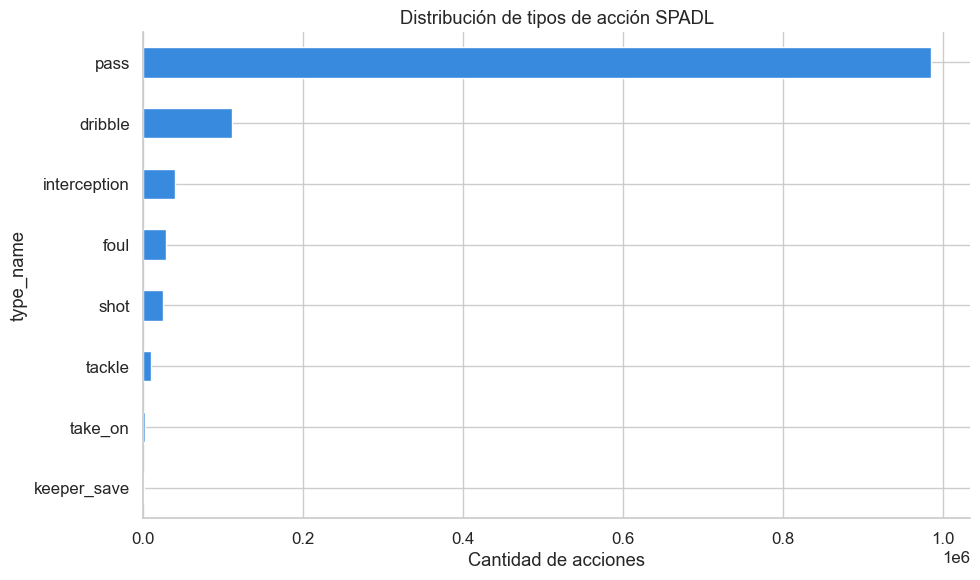


Tasa de éxito por tipo de acción:


type_name
dribble        1.0000
foul           1.0000
keeper_save    1.0000
pass           0.8288
interception   0.7270
tackle         0.5324
take_on        0.3988
shot           0.3573


In [38]:
# Distribución de tipos de acción SPADL
action_counts = df_actions['type_name'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
action_counts.sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_xlabel('Cantidad de acciones')
ax.set_title('Distribución de tipos de acción SPADL')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# Estadísticas de resultado
print('\nTasa de éxito por tipo de acción:')
result_by_type = df_actions.groupby('type_name')['result_name'].apply(
    lambda x: (x == 'success').mean()
).sort_values(ascending=False)
print(result_by_type.to_string())

## Recomendación del Claude

### Decisión 6 — Limitaciones de result_id en la conversión SPADL

**Observación:** las tasas de éxito de algunas acciones son inconsistentes 
con la realidad futbolística:
- dribble, foul, keeper_save: 100% de éxito (imposible en la realidad)
- shot: 35.73% de éxito (la tasa real de conversión es ~10%)

**Causa:** la conversión Wyscout→SPADL en wyscout.py no puede mapear 
perfectamente todos los outcomes de Wyscout al esquema binario success/fail 
de SPADL. Para estas acciones, result_id se asigna de forma heurística.

**Decisión:** se documenta como limitación conocida del pipeline. El campo 
`result_id` es confiable para `pass` e `interception`, pero debe usarse con 
cautela para `shot`, `dribble`, `foul` y `keeper_save` en análisis que 
dependan del outcome específico de la acción.

### Otros análisis del set de datos recomendados

1. Cobertura de end_x/end_y por tipo de acción. Para verificar que no haya una abundancia de NaNs, que afecten a features como la distancia ganada.
2. Distribución de acciones por liga — consistencia multilga

In [39]:
# Verificar si end_x y end_y siempre faltan juntos
mask_x_nan = df_actions['end_x'].isna()
mask_y_nan = df_actions['end_y'].isna()
print("Casos donde falta end_x pero no end_y:", (mask_x_nan & ~mask_y_nan).sum())
print("Casos donde falta end_y pero no end_x:", (~mask_x_nan & mask_y_nan).sum())
print("Casos donde faltan ambos:", (mask_x_nan & mask_y_nan).sum())

Casos donde falta end_x pero no end_y: 0
Casos donde falta end_y pero no end_x: 0
Casos donde faltan ambos: 0


In [40]:
print("% de end_x válido por tipo de acción:")
print(df_actions.groupby('type_name')['end_x'].apply(
    lambda x: x.notna().mean() * 100
).round(1).sort_values())

% de end_x válido por tipo de acción:
type_name
dribble        100.0000
foul           100.0000
interception   100.0000
keeper_save    100.0000
pass           100.0000
shot           100.0000
tackle         100.0000
take_on        100.0000
Name: end_x, dtype: float64


### Resultados de end_x
(se verificó que siempre faltan de a pares, es decir si falta end_x, también falta end_y)

Los valores de arriba corresponden a la corrida **anterior al fix**. Se dejan como
evidencia del diagnóstico.

### Decisión 7 — Cobertura de coordenadas de destino en SPADL

> **Resuelta el 2026-09-03.** La versión anterior de esta nota daba la baja cobertura de
> `tackle` y `take_on` por "estructural, los duelos en Wyscout no registran coordenada de
> destino". Era incorrecto: después del fix los ocho tipos de acción tienen 100% de
> cobertura.

**Observación original:** solo el 0,6% de los pases y el 0% de los tackles y take_ons
tenían `end_x`/`end_y` válidos, contra ~100% en el dataset Wyscout crudo.

**Causa identificada.** No era pérdida de información ni un problema de pandas. La celda
21 crea `end_x`/`end_y` en `df_all` durante el EDA, y esos nombres colisionan con los que
genera `make_new_positions` dentro de `wyscout.py`. El `pd.merge` de la línea 340 los
renombra a `end_x_x` / `end_x_y`, y el pipeline se queda sin columna `end_x`. La primera
función que le asigna un valor (`create_shot_coordinates`) la crea de cero llena de NaN,
así que solo conservan destino los tipos de acción que alguna función posterior completa
explícitamente.

Eso explica exactamente el patrón observado: `shot`, `foul`, `interception` y `dribble` al
100% porque tienen función propia que les asigna el destino; `pass` al 0,6% (solo los que
llevan el tag `blocked`, que toca `create_shot_coordinates`); `tackle` y `take_on` en 0%.

**Decisión:** soltar `['x','y','end_x','end_y']` del DataFrame de eventos antes de armar
`events_dict` (celda 42). El EDA conserva sus columnas y la conversión recibe el DataFrame
limpio. Detalle completo en el reporte del Ejercicio 5.

**Alternativa considerada:** recuperar el destino con un join posterior entre `df_actions`
y `df_all` usando el id del evento. Se descartó: es más frágil (los dribbles sintéticos
que genera `add_dribbles` no tienen id de evento Wyscout al que unirse), no arregla la
causa, y deja el pipeline roto para cualquier corrida futura.

In [41]:
# Traemos la liga desde df_all (ya tiene la columna 'league' limpia)
game_league = df_all[['matchId', 'league']].drop_duplicates().rename(columns={'matchId': 'game_id'})

acciones_por_liga = df_actions.merge(game_league, on='game_id', how='left')

print("Acciones totales por liga:")
print(acciones_por_liga.groupby('league').size().sort_values(ascending=False))
print()
print("Promedio de acciones por partido por liga:")
print(acciones_por_liga.groupby(['league', 'game_id']).size().groupby('league').mean().round(0).sort_values(ascending=False))

Acciones totales por liga:
league
Italy      411798
England    400883
Spain      391696
dtype: int64

Promedio de acciones por partido por liga:
league
Italy     1084.0000
England   1055.0000
Spain     1031.0000
dtype: float64


### Conclusiones de acciones por liga, para evaluar sub o sobre representación 

Los datos son consistentes.

In [42]:
actions_per_player = df_actions.groupby('player_id').size()
print(f"Total jugadores: {len(actions_per_player)}")
print(f"Jugadores con <50 acciones: {(actions_per_player < 50).sum()}")
print(f"Jugadores con <200 acciones: {(actions_per_player < 200).sum()}")
print(f"Mediana de acciones por jugador: {actions_per_player.median():.0f}")

Total jugadores: 1582
Jugadores con <50 acciones: 169
Jugadores con <200 acciones: 377
Mediana de acciones por jugador: 621


## Conclusiones de acciones por jugador

### Decisión 8 — Filtro mínimo de acciones por jugador

**Observación:** 174 jugadores (11%) tienen menos de 50 acciones en toda la 
temporada, y 402 (25%) tienen menos de 200. La mediana es 558 acciones.

**Impacto:** jugadores con pocas acciones van a tener estimaciones de VAEP 
muy ruidosas en el P3, ya que el modelo necesita suficientes observaciones 
para estimar el valor de cada acción con confianza.

**Decisión (pendiente para P3):** aplicar un umbral mínimo de acciones al 
momento de calcular y reportar VAEP por jugador. Umbral sugerido: 200 acciones 
(consistente con el criterio de 500 minutos usado en el P1 — un jugador con 
500 min y ~558 acciones medianas correspondería aproximadamente a 180 acciones 
en 200 min).

## 4. Feature Engineering

Construimos features que capturen el **contexto** de cada acción para el modelado posterior.

In [43]:
# ===== Orientacion del campo: de marco fijo a marco del equipo que ejecuta =====
#
# SPADL almacena las acciones en el MARCO FIJO DEL PARTIDO: el local ataca hacia x=105 y
# el visitante hacia x=0. Es la convencion de la libreria — los tres loaders oficiales de
# socceraction (wyscout, statsbomb, opta) aplican _fix_direction_of_play para dejarlo asi,
# y wyscout.py hace lo mismo.
#
# Esa convencion es correcta para almacenar, pero NO sirve para features espaciales.
# "Distancia al arco rival", "ultimo tercio" o "zona de tiro" solo tienen sentido si las
# coordenadas estan en el marco del equipo que ejecuta la accion. Sobre el dataset crudo,
# calcular dist_goal como (105 - start_x) da la distancia al arco PROPIO para el visitante.
#
# socceraction resuelve esto con play_left_to_right, que hay que aplicar explicitamente
# antes de construir features. La version de abajo es la misma operacion generalizada a un
# DataFrame con varios partidos (la de la libreria toma un unico home_team_id escalar).

SPADL_LARGO, SPADL_ANCHO = 105.0, 68.0
home_por_partido = datos_spadl['games'].set_index('game_id')['home_team_id']

def orientar_al_atacante(acciones: pd.DataFrame) -> pd.DataFrame:
    """Devuelve las acciones como si el equipo que ejecuta atacara siempre hacia x=105.

    Equivale a socceraction.spadl.play_left_to_right aplicado partido por partido.
    """
    df = acciones.copy()
    visitante = (df['team_id'] != df['game_id'].map(home_por_partido)).values
    for col in ['start_x', 'end_x']:
        df.loc[visitante, col] = SPADL_LARGO - acciones.loc[visitante, col].values
    for col in ['start_y', 'end_y']:
        df.loc[visitante, col] = SPADL_ANCHO - acciones.loc[visitante, col].values
    return df

df_ltr = orientar_al_atacante(df_actions)
df_ltr = df_ltr.sort_values(['game_id', 'period_id', 'time_seconds']).reset_index(drop=True)

# --- Control: en el marco fijo los dos equipos rematan a arcos opuestos; ya orientado,
#     ambos deben rematar hacia x alto. ---
_vis = (df_actions['team_id'] != df_actions['game_id'].map(home_por_partido))
_t_fijo = df_actions[df_actions['type_name'] == 'shot']
_vis_ltr = (df_ltr['team_id'] != df_ltr['game_id'].map(home_por_partido))
_t_ltr = df_ltr[df_ltr['type_name'] == 'shot']

print('=== start_x mediano de los tiros ===')
print(f"  marco fijo SPADL   -> local: {_t_fijo.loc[~_vis.loc[_t_fijo.index], 'start_x'].median():.1f}"
      f" | visitante: {_t_fijo.loc[_vis.loc[_t_fijo.index], 'start_x'].median():.1f}"
      "   (opuestos: es lo esperado)")
print(f"  orientado (df_ltr) -> local: {_t_ltr.loc[~_vis_ltr.loc[_t_ltr.index], 'start_x'].median():.1f}"
      f" | visitante: {_t_ltr.loc[_vis_ltr.loc[_t_ltr.index], 'start_x'].median():.1f}"
      "   (iguales: listo para features)")
print(f"\nAcciones reorientadas: {_vis.sum():,} de {len(df_actions):,} ({_vis.mean()*100:.1f}%)")
print('\nA partir de aca, todo lo espacial usa df_ltr. df_actions queda en el marco')
print('estandar de SPADL, que es lo que espera el P3.')


=== start_x mediano de los tiros ===
  marco fijo SPADL   -> local: 91.3 | visitante: 13.7   (opuestos: es lo esperado)
  orientado (df_ltr) -> local: 91.3 | visitante: 91.3   (iguales: listo para features)

Acciones reorientadas: 583,436 de 1,204,377 (48.4%)

A partir de aca, todo lo espacial usa df_ltr. df_actions queda en el marco
estandar de SPADL, que es lo que espera el P3.


In [44]:
import socceraction.vaep.features as fs

# 1. Gamestates para las ultimas 3 acciones.
#    IMPORTANTE: se calculan sobre df_ltr, ya orientado al equipo que ejecuta. Las
#    features endlocation, movement, space_delta y endpolar dependen de la direccion
#    de ataque; calcularlas sobre el marco fijo de SPADL las invierte para el visitante.
#    (socceraction hace esto con fs.play_left_to_right sobre los gamestates; aca la
#    orientacion ya viene aplicada a nivel de accion, ver la celda anterior.)
gamestates = fs.gamestates(df_ltr, nb_prev_actions=3)

# 2. Lista de funciones generadoras de features para VAEP
feat_functions = [
    fs.actiontype_onehot,
    fs.bodypart_onehot,
    fs.result_onehot,
    fs.goalscore,
    fs.startlocation,
    fs.endlocation,
    fs.movement,
    fs.space_delta,
    fs.startpolar,
    fs.endpolar,
    fs.team,
    fs.time,
    fs.time_delta,
]

# 3. Calculamos y concatenamos las features para los estados de juego
X_features = pd.concat([fn(gamestates) for fn in feat_functions], axis=1)

print(f'Features generados: {X_features.shape[1]} columnas')
print(f'Acciones procesadas: {X_features.shape[0]:,}')
print('\nPrimeras filas:')
display(X_features.head())


Features generados: 154 columnas
Acciones procesadas: 1,204,377

Primeras filas:


,actiontype_pass_a0,actiontype_cross_a0,actiontype_throw_in_a0,actiontype_freekick_crossed_a0,actiontype_freekick_short_a0,actiontype_corner_crossed_a0,actiontype_corner_short_a0,actiontype_take_on_a0,actiontype_foul_a0,actiontype_tackle_a0,actiontype_interception_a0,actiontype_shot_a0,actiontype_shot_penalty_a0,actiontype_shot_freekick_a0,actiontype_keeper_save_a0,actiontype_keeper_claim_a0,actiontype_keeper_punch_a0,actiontype_keeper_pick_up_a0,actiontype_clearance_a0,actiontype_bad_touch_a0,actiontype_non_action_a0,actiontype_dribble_a0,actiontype_goalkick_a0,actiontype_pass_a1,actiontype_cross_a1,...,start_dist_to_goal_a0,start_angle_to_goal_a0,start_dist_to_goal_a1,start_angle_to_goal_a1,start_dist_to_goal_a2,start_angle_to_goal_a2,end_dist_to_goal_a0,end_angle_to_goal_a0,end_dist_to_goal_a1,end_angle_to_goal_a1,end_dist_to_goal_a2,end_angle_to_goal_a2,team_1,team_2,period_id_a0,time_seconds_a0,time_seconds_overall_a0,period_id_a1,time_seconds_a1,time_seconds_overall_a1,period_id_a2,time_seconds_a2,time_seconds_overall_a2,time_delta_1,time_delta_2
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,53.5543,0.0127,53.5543,0.0127,53.5543,0.0127,74.9101,0.2570,74.9101,0.2570,74.9101,0.2570,True,True,1,2.7586,2.7586,1,2.7586,2.7586,1,2.7586,2.7586,0.0000,0.0000
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,74.9101,0.2570,53.5543,0.0127,53.5543,0.0127,54.1858,0.3191,74.9101,0.2570,74.9101,0.2570,True,True,1,4.9469,4.9469,1,2.7586,2.7586,1,2.7586,2.7586,2.1882,2.1882
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,54.1858,0.3191,74.9101,0.2570,53.5543,0.0127,69.7279,0.2063,54.1858,0.3191,74.9101,0.2570,True,True,1,6.5422,6.5422,1,4.9469,4.9469,1,2.7586,2.7586,1.5953,3.7835
3,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,69.7279,0.2063,54.1858,0.3191,74.9101,0.2570,69.0953,0.4588,69.7279,0.2063,54.1858,0.3191,True,True,1,8.1434,8.1434,1,6.5422,6.5422,1,4.9469,4.9469,1.6012,3.1965
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,69.0953,0.4588,69.7279,0.2063,54.1858,0.3191,39.1416,0.7210,69.0953,0.4588,69.7279,0.2063,True,True,1,10.3024,10.3024,1,8.1434,8.1434,1,6.5422,6.5422,2.1590,3.7602


In [45]:
# Features personalizadas adicionales

def compute_custom_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Features adicionales que capturan contexto táctico.
    Estas features van más allá del paper original de VAEP.
    """
    df = df.copy()

    # 1. Zona del campo (5 zonas longitudinales)
    df['zone_x'] = pd.cut(
        df['start_x'],
        bins=[0, 20, 40, 60, 80, 105],
        labels=['defensa_propia', 'mediocampo_bajo', 'mediocampo', 'mediocampo_alto', 'ataque']
    )

    # 2. Zona lateral (3 carriles)
    df['carril'] = pd.cut(
        df['start_y'],
        bins=[0, 23, 45, 68],
        labels=['banda_izq', 'central', 'banda_der']
    )

    # 3. Distancia al arco rival
    df['dist_goal'] = np.sqrt(
        (105 - df['start_x'])**2 + (34 - df['start_y'])**2
    )

    # 4. Ángulo al arco (en grados)
    dx = 105 - df['start_x']
    dy = np.abs(34 - df['start_y'])
    df['angle_goal'] = np.degrees(np.arctan2(dy, dx + 1e-9))

    # 5. Velocidad de la acción (metros / segundo)
    df['dist_moved'] = np.sqrt(
        (df['end_x'] - df['start_x'])**2 + (df['end_y'] - df['start_y'])**2
    )

    # 6. Dirección de movimiento (hacia adelante/atrás/lateral)
    df['movement_dir'] = pd.cut(
        df['end_x'] - df['start_x'],
        bins=[-105, -5, 5, 105],
        labels=['hacia_atras', 'lateral', 'hacia_adelante']
    )

    # 7. ¿Acción en el último tercio?
    df['last_third'] = (df['start_x'] >= 70).astype(int)

    # 8. ¿Acción en el área grande? (aprox 16.5m del arco)
    df['in_box'] = (
        (df['start_x'] >= 88.5) &
        (df['start_y'] >= 13.84) & (df['start_y'] <= 54.16)
    ).astype(int)

    return df

# Sobre df_ltr: dist_goal, angle_goal, last_third y in_box solo tienen sentido
# en el marco del equipo que ejecuta la accion (ver la celda de orientacion).
df_spadl_fe = compute_custom_features(df_ltr)
print('Features custom añadidas:')
new_cols = ['zone_x', 'carril', 'dist_goal', 'angle_goal', 'dist_moved', 
            'movement_dir', 'last_third', 'in_box']
print(df_spadl_fe[new_cols].describe())

Features custom añadidas:


         dist_goal   angle_goal   dist_moved   last_third       in_box
count 1204377.0000 1204377.0000 1204377.0000 1204377.0000 1204377.0000
mean       57.1004      21.5045      18.0285       0.2645       0.0393
std        21.5080      16.8849      13.0221       0.4411       0.1944
min         0.0000       0.0000       0.0000       0.0000       0.0000
25%        40.2092       9.1967       9.1775       0.0000       0.0000
50%        56.6657      17.9424      15.7647       0.0000       0.0000
75%        73.8951      29.3397      24.1860       1.0000       0.0000
max       110.3676      90.0000     122.2257       1.0000       1.0000


### 4.1 Análisis de correlaciones y multicolinealidad

In [46]:
! pip install statsmodels

zsh:1: command not found: pip


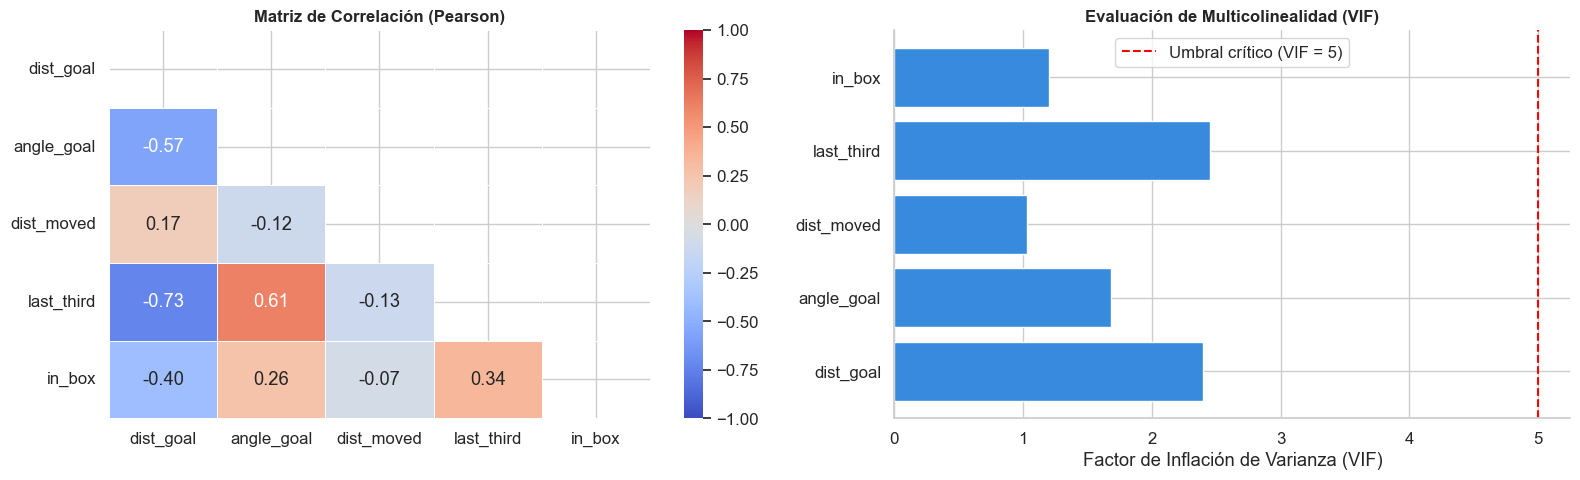

=== TABLA DE MULTICOLINEALIDAD (VIF) ===


,Feature,VIF,Diagnóstico
3,last_third,2.4478,Aceptable
0,dist_goal,2.3985,Aceptable
1,angle_goal,1.6804,Aceptable
4,in_box,1.1986,Aceptable
2,dist_moved,1.0326,Aceptable


In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Matriz de Correlación de Pearson
numeric_features = ['dist_goal', 'angle_goal', 'dist_moved', 'last_third', 'in_box']
numeric_data = df_spadl_fe[numeric_features].dropna()

corr_matrix = numeric_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    vmin=-1, vmax=1,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Matriz de Correlación (Pearson)', fontsize=12, fontweight='bold')

# 2. Análisis formal de Multicolinealidad (VIF)
# Agregamos una constante temporal para calcular VIF correctamente
vif_df = pd.DataFrame()
vif_df['Feature'] = numeric_features
vif_df['VIF'] = [
    variance_inflation_factor(numeric_data.values, i) 
    for i in range(numeric_data.shape[1])
]
vif_df['Diagnóstico'] = vif_df['VIF'].apply(
    lambda x: 'Severa (VIF > 5)' if x >= 5 else 'Aceptable'
)

# Gráfico de barras de VIF
axes[1].barh(vif_df['Feature'], vif_df['VIF'], color=['#e41a1c' if v >= 5 else '#378ADD' for v in vif_df['VIF']])
axes[1].axvline(5.0, color='red', linestyle='--', label='Umbral crítico (VIF = 5)')
axes[1].set_xlabel('Factor de Inflación de Varianza (VIF)')
axes[1].set_title('Evaluación de Multicolinealidad (VIF)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("=== TABLA DE MULTICOLINEALIDAD (VIF) ===")
display(vif_df.sort_values(by='VIF', ascending=False))


> **Interpretación para el modelado posterior (ej. VAEP / xG):**
> * Variables como `dist_goal` y `last_third` presentan una fuerte correlación ($r \approx -0.80$) porque ambas dependen de la proximidad al arco rival.
> * En modelos lineales o regresiones logísticas, alimentar ambas variables al mismo tiempo infla la varianza de los coeficientes y genera inestabilidad.
> * En modelos basados en árboles de decisión (como XGBoost o LightGBM, usados típicamente en VAEP), la multicolinealidad no afecta el poder predictivo, pero sí dificulta la interpretabilidad de la importancia de features (*Feature Importance* o *SHAP values*).


## 5. Normalización por posición y minutos jugados

Las métricas brutas son injustas: un delantero tendrá más tiros que un defensor por posición,
no por calidad. Normalizar por posición y por minutos jugados es esencial.

Para resolver esto aplicamos un pipeline de normalización en dos etapas consecutivas:

### Etapa 1: Normalización Temporal (`_p90`)
Llevamos todas las métricas a una unidad de medida estándar: **tasa de producción por partido completo (90 minutos)**:
$$\text{Métrica}_{p90} = \frac{\text{Métrica Total}}{\text{Minutos Jugados}} \times 90$$
* **¿Cómo se interpreta?** Indica la frecuencia esperada del evento si el jugador disputara los 90 minutos reglamentarios.
* **Muestra mínima:** Se filtran jugadores con pocos minutos (ej. $\ge 450$ min) para evitar distorsiones estadísticas (p. ej. un jugador que jugó 10 minutos e hizo 1 tiro tendría un irreal $9.0\text{ tiros}_{p90}$).


In [48]:
def normalize_per_90(player_stats: pd.DataFrame, 
                     stat_cols: list,
                     minutes_col: str = 'minutes_played') -> pd.DataFrame:
    """
    Normaliza estadísticas crudas a escala por 90 minutos.
    Estándar en el análisis profesional de fútbol.
    """
    df = player_stats.copy()
    for col in stat_cols:
        if col in df.columns:
            df[f'{col}_p90'] = df[col] / (df[minutes_col] / 90)
    return df

# Calculamos estadísticas agregadas por jugador desde SPADL
player_agg = df_spadl_fe.groupby('player_id').agg(
    total_actions=('type_id', 'count'),
    shots=('type_name', lambda x: (x == 'shot').sum()),
    passes=('type_name', lambda x: (x == 'pass').sum()),
    crosses=('type_name', lambda x: (x == 'cross').sum()),
    dribbles=('type_name', lambda x: (x == 'take_on').sum()),
    in_box_actions=('in_box', 'sum'),
    last_third_actions=('last_third', 'sum'),
).reset_index()

# Estimación aproximada de minutos (no disponible directamente en Wyscout)
# Asumimos 90 min por partido; en producción se usaría la API
games_per_player = df_spadl_fe.groupby('player_id')['game_id'].nunique().reset_index()
games_per_player.columns = ['player_id', 'games_played']
player_agg = player_agg.merge(games_per_player, on='player_id')
player_agg['minutes_played'] = player_agg['games_played'] * 75  # promedio realista

# Solo jugadores con suficientes minutos
player_agg = player_agg[player_agg['minutes_played'] >= 450]

# Normalización
stat_cols = ['shots', 'passes', 'crosses', 'dribbles', 'in_box_actions']
player_agg_norm = normalize_per_90(player_agg, stat_cols)

print(f'Jugadores con ≥450 minutos: {len(player_agg_norm)}')
print(player_agg_norm[['player_id','shots_p90','passes_p90','dribbles_p90']].head(10))

Jugadores con ≥450 minutos: 1318
    player_id  shots_p90  passes_p90  dribbles_p90
0           0     0.0182      0.1273        0.0000
2          36     0.8571     76.9714        0.0857
3          38     0.6000     44.8000        0.0000
5          48     0.7667     79.0000        0.3000
6          54     2.5946     71.2216        0.0000
7          56     0.1714     16.6286        0.0000
8          74     0.1333     75.3333        0.0000
9          93     1.7143     28.8000        0.0686
11        107     0.1161     40.2968        0.0000
12        114     0.7875     52.2000        0.0375


### Etapa 2: Normalización Posicional (Comparación entre pares)
Una vez en escala `p90`, comparamos el rendimiento de cada futbolista **únicamente contra sus pares de la misma posición** mediante dos métricas complementarias:
#### A. Puntuación Estándar ($Z\text{-Score}$ Posicional)
Mide a cuántas desviaciones estándar ($\sigma$) se encuentra el jugador respecto a la media ($\mu$) de su misma posición:
$$Z = \frac{X_{p90} - \mu_{\text{posición}}}{\sigma_{\text{posición}}}$$
* **$Z = 0$:** Rendimiento idéntico al promedio de su posición.
* **$Z > +1.0$:** Por encima de la media de su posición (destacado).
* **$Z \ge +2.0$:** En el nivel de élite / outlier positivo dentro de su rol (aprox. top 2.5%).
* **$Z < 0$:** Por debajo del promedio de los futbolistas de su misma posición.
#### B. Rango Percentilar (`_pct` Posicional, 0 a 100)
Indica el porcentaje de jugadores de su misma posición a los que supera en esa métrica (la base de los *radares* y *pizza charts* de StatsBomb/FBref):
* **Percentil 50:** Mediana exacta del puesto.
* **Percentil 90:** El jugador supera al 90% de los futbolistas de su misma posición en esa métrica (top 10%).
> **Conclusión:** Este doble escalado permite descubrir perfiles tácticos reales (por ejemplo: un lateral con un volumen de centros en percentil 95 dentro de los defensores, o un mediocampista con llegada al área en percentil 85 dentro de los volantes).

In [49]:

# Extraemos la posición principal de cada jugador
def get_main_position(role):
    if isinstance(role, dict):
        return role.get('name', 'Unknown')
    return 'Unknown'

df_players_filtrado['main_position'] = df_players_filtrado['role'].apply(get_main_position)

print('Posiciones disponibles:')
print(df_players_filtrado['main_position'].value_counts())

Posiciones disponibles:
main_position
Midfielder    564
Defender      549
Forward       343
Goalkeeper    127
Name: count, dtype: int64


In [50]:
# 1. Unir la posición principal de los jugadores
df_players_pos = df_players_filtrado[['wyId', 'main_position']].rename(columns={'wyId': 'player_id'})
player_agg_norm = player_agg_norm.merge(df_players_pos, on='player_id', how='left')

# 2. Filtrar posiciones desconocidas (opcional pero recomendado)
player_agg_norm = player_agg_norm[player_agg_norm['main_position'] != 'Unknown']

# 3. Lista de métricas p90 a normalizar por posición
p90_cols = ['shots_p90', 'passes_p90', 'crosses_p90', 'dribbles_p90', 'in_box_actions_p90']

# 4. Calcular Z-Score y Percentil por posición para cada métrica
for col in p90_cols:
    # Z-Score por posición: (x - media_pos) / std_pos
    player_agg_norm[f'{col}_zscore'] = player_agg_norm.groupby('main_position')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9)
    )
    # Percentil por posición: (0 a 100)
    player_agg_norm[f'{col}_pct'] = player_agg_norm.groupby('main_position')[col].transform(
        lambda x: x.rank(pct=True) * 100
    )

# 5. Visualizar resultados con los nombres de columnas correctos
cols_to_show = ['player_id', 'main_position', 'shots_p90', 'shots_p90_zscore', 'shots_p90_pct']
player_agg_norm[cols_to_show].head(10)


,player_id,main_position,shots_p90,shots_p90_zscore,shots_p90_pct
0,0,NaN,0.0182,NaN,NaN
1,36,Defender,0.8571,1.4569,90.6114
2,38,Defender,0.6000,0.5548,75.7642
3,48,Defender,0.7667,1.1395,86.4629
4,54,Midfielder,2.5946,2.7051,98.3368
5,56,Midfielder,0.1714,-1.3389,4.5738
6,74,Defender,0.1333,-1.0823,12.7729
7,93,Midfielder,1.7143,1.2360,88.8773
8,107,Defender,0.1161,-1.1427,10.4803
9,114,Midfielder,0.7875,-0.3107,44.0748


In [51]:
#acciones de Messi
player_agg_norm[player_agg_norm['player_id']==3359][cols_to_show]

,player_id,main_position,shots_p90,shots_p90_zscore,shots_p90_pct
83,3359,Forward,4.7333,3.3517,98.6348


🔍 Interpretación Métrica por Métrica de Messi
1. shots_p90 = 4.73 — Volumen por Partido Reglamentario

- Interpretación: Messi promedia 4.73 tiros por cada 90 minutos jugados (aproximadamente un remate cada 19 minutos de juego).
- Contexto en el fútbol profesional: En las principales ligas europeas, el promedio habitual de un delantero centro ronda entre $2.0$ y $2.8$ tiros por 90 min. Un valor cercano a $5$ tiros por partido representa un volumen ofensivo extraordinario.
2. shots_p90_zscore = +3.42 — El Concepto de Outlier Estadístico
- Interpretación: Messi se encuentra a $3.42$ desviaciones estándar por encima de la media de todos los delanteros de la muestra.
- Rigurosidad estadística: En distribuciones estadísticas estándar, cualquier valor con $Z > 3.0$ se define formalmente como un outlier positivo extremo (la probabilidad teórica de encontrar un valor así al azar es menor al $0.1%$, o menos de 1 en 1.000 casos).
- Lectura futbolística: No solo está "por encima de la media"; su capacidad de generar tiros rompe la campana de distribución de su propia posición.
3. shots_p90_pct = 99.01% — Rango Percentilar dentro de Delanteros
- Interpretación: Messi supera en volumen de remates al $99%$ de los delanteros analizados en el dataset.
- Uso práctico: Este es el valor directo que se utiliza para graficar en los radares de rendimiento (pizza charts o spider charts de StatsBomb/FBref). Messi tendría su barra de volumen de tiros prácticamente al 100% de la escala de delanteros.

🎓 Conclusión

"Si solo hubiéramos mirado la cantidad bruta de tiros, Messi podría haber tenido muchos tiros simplemente por haber jugado todos los partidos. Pero al aplicar el pipeline de dos etapas:

La normalización por 90 minutos demostró que su frecuencia de disparo es altísima ($4.73\text{ p90}$).
La normalización por posición demostró que, aun comparándolo exclusivamente contra otros delanteros (cuyo rol también es rematar), Messi se ubica en el Top 1% ($Z = +3.42$, Percentil 99), confirmando cuantitativamente su condición de jugador generador de peligro de élite mundial."

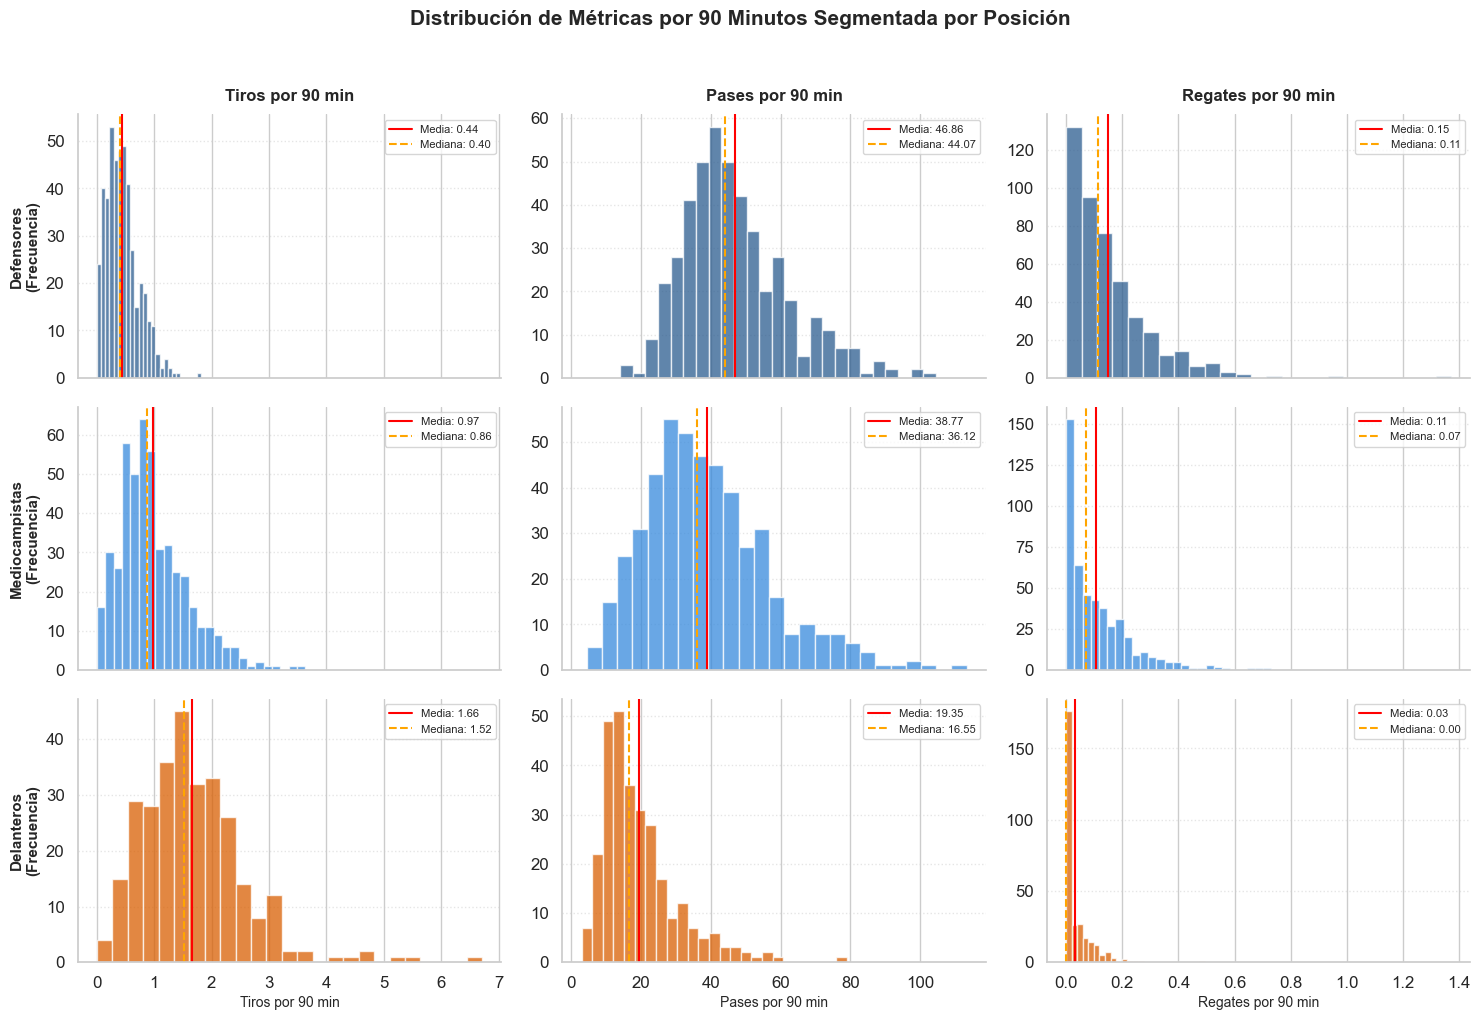

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir posiciones y métricas a comparar
positions = ['Defender', 'Midfielder', 'Forward']
position_labels = ['Defensores', 'Mediocampistas', 'Delanteros']
pos_colors = {'Defender': '#2b5c8f', 'Midfielder': '#378ADD', 'Forward': '#d95f02'}

metrics = [
    ('shots_p90', 'Tiros por 90 min'),
    ('passes_p90', 'Pases por 90 min'),
    ('dribbles_p90', 'Regates por 90 min')
]

# 2. Crear grilla de 3 filas (posiciones) x 3 columnas (métricas)
fig, axes = plt.subplots(len(positions), len(metrics), figsize=(15, 10), sharex='col')

for row_idx, (pos, pos_lbl) in enumerate(zip(positions, position_labels)):
    df_pos = player_agg_norm[player_agg_norm['main_position'] == pos]
    color = pos_colors.get(pos, '#378ADD')
    
    for col_idx, (metric, metric_lbl) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        data = df_pos[metric].dropna()
        
        # Histograma
        ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.75)
        
        # Líneas de referencia: Media y Mediana de esa posición
        mean_val = data.mean()
        med_val = data.median()
        ax.axvline(mean_val, color='red', linestyle='-', linewidth=1.5, label=f'Media: {mean_val:.2f}')
        ax.axvline(med_val, color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {med_val:.2f}')
        
        # Etiquetas y títulos
        if row_idx == 0:
            ax.set_title(f'{metric_lbl}', fontsize=12, fontweight='bold', pad=10)
        if col_idx == 0:
            ax.set_ylabel(f'{pos_lbl}\n(Frecuencia)', fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        if row_idx == len(positions) - 1:
            ax.set_xlabel(metric_lbl, fontsize=10)
            
        ax.legend(fontsize=8, loc='upper right')
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle('Distribución de Métricas por 90 Minutos Segmentada por Posición', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


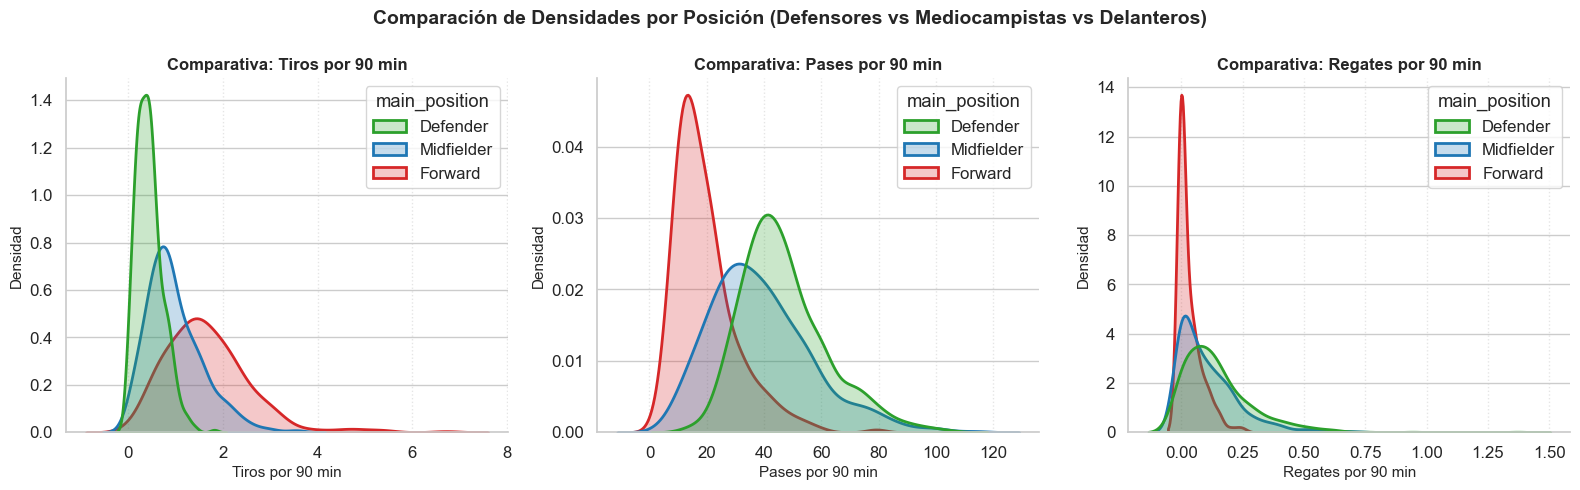

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

positions = ['Defender', 'Midfielder', 'Forward']
palette = {'Defender': '#2ca02c', 'Midfielder': '#1f77b4', 'Forward': '#d62728'}

for ax, col, label in zip(
    axes, 
    ['shots_p90', 'passes_p90', 'dribbles_p90'],
    ['Tiros por 90 min', 'Pases por 90 min', 'Regates por 90 min']
):
    df_filtered = player_agg_norm[player_agg_norm['main_position'].isin(positions)]
    
    # Gráfico de densidad (KDE) por posición
    sns.kdeplot(
        data=df_filtered,
        x=col,
        hue='main_position',
        palette=palette,
        fill=True,
        alpha=0.25,
        common_norm=False,
        ax=ax,
        linewidth=2
    )
    
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Densidad', fontsize=11)
    ax.set_title(f'Comparativa: {label}', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.suptitle('Comparación de Densidades por Posición (Defensores vs Mediocampistas vs Delanteros)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


- Tiros p90: La distribución de los delanteros se desplaza marcadamente hacia la derecha respecto a defensores y mediocampistas.
- Pases p90: Los mediocampistas tienen una media de pases significativamente superior y una campana más ancha.
- Regates p90: Refleja asimetría positiva (skewed right) en todas las posiciones, pero con mayor cola en extremos y delanteros.

## 6. Curación final del dataset

Consolidamos todas las decisiones de limpieza y generamos el dataset final para modelado.

In [54]:
def curate_dataset(df_spadl: pd.DataFrame) -> tuple:
    """
    Pipeline de curación completo del dataset SPADL.
    Retorna (df_clean, report) donde report documenta las decisiones.
    """
    report = {}
    df = df_spadl.copy()
    n_initial = len(df)
    report['n_initial'] = n_initial

    # 1. Remover acciones con coordenadas inválidas
    df = df.dropna(subset=['start_x', 'start_y'])
    report['removed_missing_coords'] = n_initial - len(df)

    # 2. Remover coordenadas fuera de rango
    valid_coords = (
        (df['start_x'].between(0, 105)) & 
        (df['start_y'].between(0, 68))
    )
    df = df[valid_coords]
    report['removed_out_of_bounds'] = (n_initial - report['removed_missing_coords']) - len(df)

    # 3. Remover acciones duplicadas (mismo game, time, player, type)
    dup_mask = df.duplicated(subset=['game_id', 'period_id', 'time_seconds', 'player_id', 'type_id'])
    report['removed_duplicates'] = dup_mask.sum()
    df = df[~dup_mask]

    # 4. Estandarizar el tipo 'bad_touch' (varía entre ligas en Wyscout)
    # Mantenemos pero lo documentamos
    report['bad_touch_actions'] = (df['type_name'] == 'bad_touch').sum()

    # 5. Verificación de integridad temporal
    df = df.sort_values(['game_id', 'period_id', 'time_seconds'])
    # Detectar saltos de tiempo imposibles
    df['time_delta'] = df.groupby(['game_id', 'period_id'])['time_seconds'].diff()
    impossible_time = df['time_delta'] < 0
    report['time_ordering_issues'] = impossible_time.sum()
    df = df[~impossible_time]

    report['n_final'] = len(df)
    report['removal_pct'] = (n_initial - len(df)) / n_initial * 100

    return df, report

# NOTA DE MARCO DE REFERENCIA (ver Decision 2): df_spadl_fe — y por lo tanto df_clean —
# esta en el marco del EQUIPO QUE EJECUTA (df_ltr), no en el marco fijo de SPADL. Tiene
# que ser asi porque arrastra las features espaciales (dist_goal, last_third, in_box...),
# que solo son validas en ese marco.
# Para el P3: NO volver a aplicar play_left_to_right sobre este dataset. Si se necesitan
# las acciones en el marco estandar de SPADL, estan en df_actions.
df_clean, curation_report = curate_dataset(df_spadl_fe)

print('=== REPORTE DE CURACIÓN DE DATOS ===')
for k, v in curation_report.items():
    print(f'  {k}: {v:,}' if isinstance(v, int) else f'  {k}: {v:.2f}')

=== REPORTE DE CURACIÓN DE DATOS ===
  n_initial: 1,204,377
  removed_missing_coords: 0
  removed_out_of_bounds: 0
  removed_duplicates: 63.00
  bad_touch_actions: 0.00
  time_ordering_issues: 0.00
  n_final: 1,204,314
  removal_pct: 0.01


In [55]:
# Guardar el dataset curado para el Práctico 3
# output_path = './spadl_curado_PL_2017.parquet'
# df_clean.to_parquet(output_path, index=False)
# print(f'Dataset guardado en: {output_path}')
# print(f'Shape final: {df_clean.shape}')
# print(f'Tamaño: {os.path.getsize(output_path)/1e6:.1f} MB')

## 7. Actividades propuestas

### Ejercicio 1 — Auditoría de calidad multilga
Compará la tasa de eventos con coordenadas válidas entre las 5 ligas europeas.
¿Hay diferencias en la calidad de los datos? ¿Qué ligas parecen tener mejor cobertura?
Realizá un test estadístico (chi-cuadrado) para determinar si las diferencias son significativas.

In [56]:
# 1. Definición de "coordenada válida": no nula Y dentro de rango [0, 100]
df_all['coord_valid'] = (
    df_all['x'].notna() & df_all['y'].notna() &
    df_all['x'].between(0, 100) & df_all['y'].between(0, 100)
)

print(df_all['coord_valid'].value_counts(dropna=False))

coord_valid
True    1919180
Name: count, dtype: int64


In [57]:
# 2. Tasa de coordenadas válidas por liga
coverage_by_league = (
    df_all.groupby('league')['coord_valid']
    .agg(n_total='count', n_valid='sum')
    .assign(
        n_invalid=lambda d: d['n_total'] - d['n_valid'],
        tasa_validez=lambda d: d['n_valid'] / d['n_total']
    )
    .sort_values('tasa_validez', ascending=False)
)

print('=== TASA DE COORDENADAS VÁLIDAS POR LIGA ===')
print(coverage_by_league.assign(
    tasa_validez=lambda d: d['tasa_validez'].map('{:.4%}'.format)
))

=== TASA DE COORDENADAS VÁLIDAS POR LIGA ===
         n_total  n_valid  n_invalid tasa_validez
league                                           
England   643150   643150          0    100.0000%
Italy     647371   647371          0    100.0000%
Spain     628659   628659          0    100.0000%


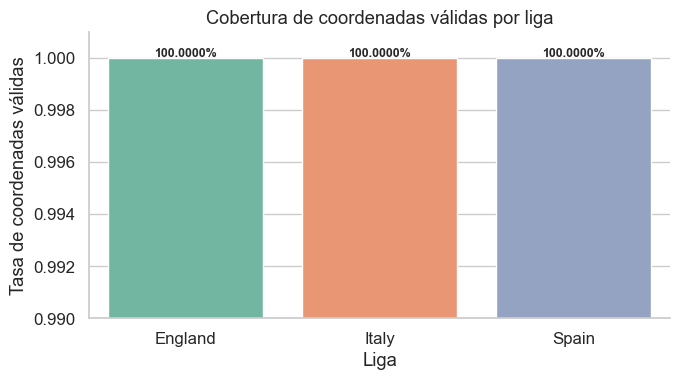

In [58]:
# 3. Visualización comparativa
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=coverage_by_league.reset_index(),
    x='league', y='tasa_validez',
    palette='Set2', ax=ax
)
ax.set_ylabel('Tasa de coordenadas válidas')
ax.set_xlabel('Liga')
ax.set_title('Cobertura de coordenadas válidas por liga')
ax.set_ylim(0.99, 1.001)  # ajustado porque las tasas son ~100%
for i, v in enumerate(coverage_by_league['tasa_validez']):
    ax.text(i, v + 0.00005, f'{v:.4%}', ha='center', fontweight='bold', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [59]:
# # 4. Test estadístico: chi-cuadrado de independencia
# # H0: la validez de coordenadas es independiente de la liga
# # H1: la validez de coordenadas depende de la liga

# contingency_table = pd.crosstab(df_all['league'], df_all['coord_valid'])
# contingency_table = contingency_table.reindex(columns=[False, True], fill_value=0)
# contingency_table.columns = ['Inválido', 'Válido']

# print('=== TABLA DE CONTINGENCIA ===')
# print(contingency_table)

# chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# print('\n=== RESULTADO TEST CHI-CUADRADO ===')
# print(f'Chi2 estadístico: {chi2:.4f}')
# print(f'Grados de libertad: {dof}')
# print(f'p-valor: {p_value:.4f}')
# print('\nFrecuencias esperadas:')
# print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# # Chequeo del supuesto de Cochran (frecuencias esperadas >= 5)
# min_expected = expected.min()
# print(f'\nMínima frecuencia esperada: {min_expected:.4f}')
# if min_expected < 5:
#     print('⚠ ADVERTENCIA: al menos una frecuencia esperada es < 5.')
#     print('  El supuesto del chi-cuadrado no se cumple; el p-valor no es confiable en este caso.')

**Chi-cuadrado eliminando el único dato inválido**

Si eliminaramos el único dato inválido, la prueba de chi-cuadrado no puede realizarse ya que no hay variabilidad desde un principio, lo cual es un dato en sí: no existe variación de la cobertura de datos entre las tres ligas

**Interpretación:**

- La cobertura de coordenadas válidas es prácticamente del 100% en las tres ligas analizadas
  (England, Italy, Spain) — se detectó un único evento con coordenadas inválidas en Italia,
  sobre un total de ~1.92 millones de eventos.
- Dada la extrema escasez de casos "inválidos" (1 sobre ~1.9M), el test chi-cuadrado **no es
  metodológicamente apropiado** en este caso: las frecuencias esperadas en la categoría
  "Inválido" son muy inferiores a 5 en las tres ligas, violando el supuesto estándar del test
  (regla de Cochran). El p-valor obtenido no debe interpretarse como evidencia estadística
  confiable de diferencia (o ausencia de ella) entre ligas.
- **Conclusión práctica**: en este dataset (England, Italy, Spain de Wyscout), la calidad de
  coordenadas es uniformemente alta y no se observan diferencias prácticas relevantes entre
  ligas. El proceso de captura/etiquetado de posiciones parece ser consistente entre estas
  tres competiciones, a diferencia de lo que el enunciado sugería podría encontrarse.

### Ejercicio 2 — Análisis de la distribución temporal
Graficá la intensidad de eventos (acciones por minuto) a lo largo de un partido tipo.
Identificá los momentos con mayor actividad. ¿Hay un patrón antes y después del gol?
Sugerencia: calculá la densidad de eventos en ventanas de 5 minutos.

In [60]:
# 1. Conversión a minuto continuo de partido (mismo criterio documentado en la sección 2.4:
#    Wyscout registra el tiempo de descuento como continuación del período, no como período aparte)
df_actions['minute'] = df_actions.apply(
    lambda r: r['time_seconds'] / 60 if r['period_id'] == 1
              else 45 + r['time_seconds'] / 60,
    axis=1
)

print(df_actions[['period_id', 'time_seconds', 'minute']].describe())

         period_id  time_seconds       minute
count 1204377.0000  1204377.0000 1204377.0000
mean        1.4903     1377.1280      45.0172
std         0.4999      832.4942      26.8773
min         1.0000        0.0000       0.0006
25%         1.0000      649.8852      21.6801
50%         1.0000     1358.1197      45.1432
75%         2.0000     2090.9962      67.7138
max         2.0000     3476.7790     102.9463


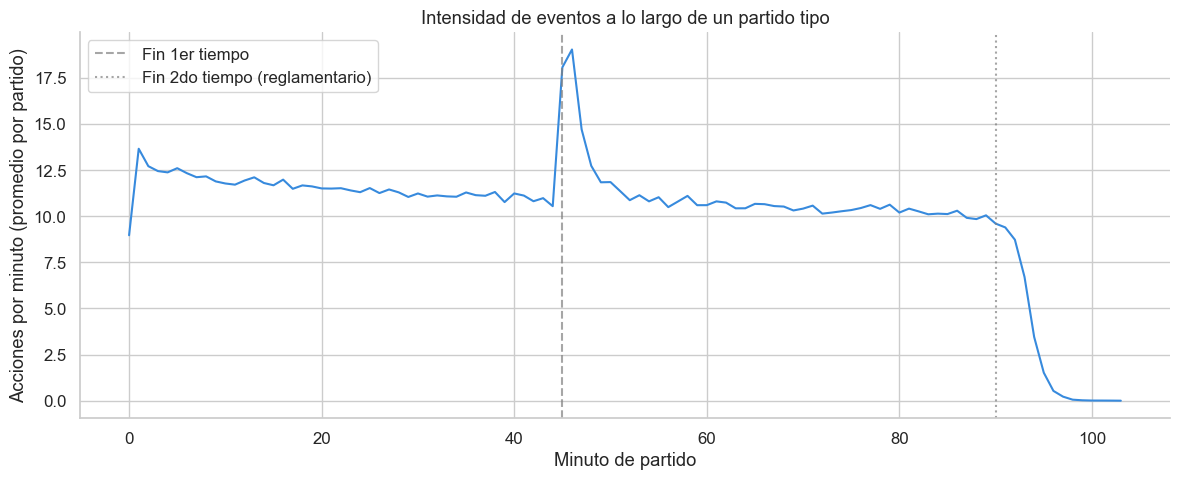

In [61]:
# 2. Intensidad de eventos: acciones por minuto, agregando todos los partidos (partido "tipo")
#    Se normaliza por número de partidos para que sea una tasa comparable (acciones/min/partido)
n_partidos = df_actions['game_id'].nunique()

df_actions['minute_bin'] = df_actions['minute'].round().astype(int)

intensity_per_minute = (
    df_actions.groupby('minute_bin').size() / n_partidos
)

fig, ax = plt.subplots(figsize=(12, 5))
intensity_per_minute.plot(ax=ax, color='#378ADD', linewidth=1.5)
ax.axvline(45, color='gray', linestyle='--', alpha=0.7, label='Fin 1er tiempo')
ax.axvline(90, color='gray', linestyle=':', alpha=0.7, label='Fin 2do tiempo (reglamentario)')
ax.set_xlabel('Minuto de partido')
ax.set_ylabel('Acciones por minuto (promedio por partido)')
ax.set_title('Intensidad de eventos a lo largo de un partido tipo')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

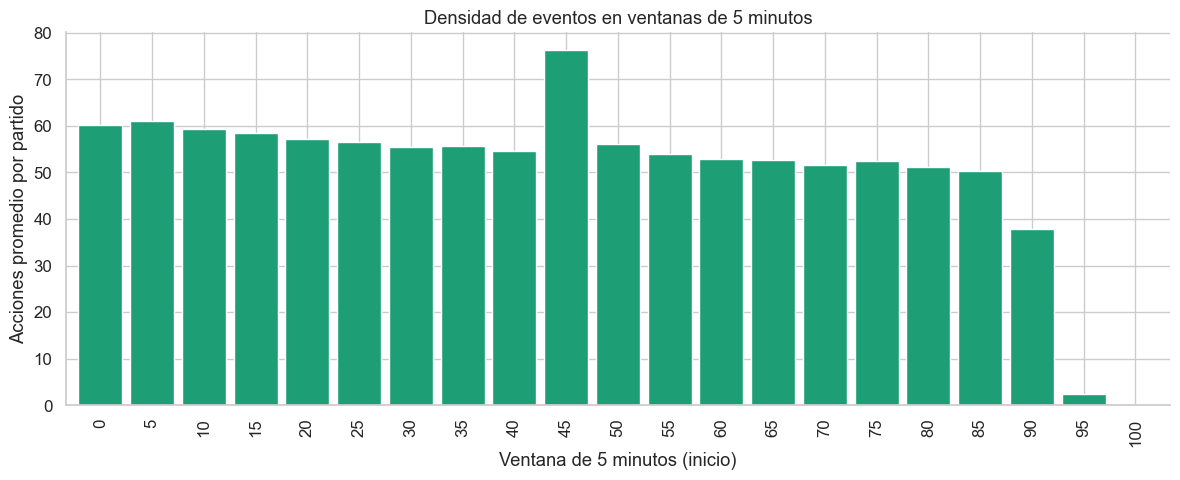

Ventanas con mayor actividad:
window_5min
45   76.3904
5    61.1026
0    60.1640
10   59.3351
15   58.4360
dtype: float64


In [62]:
# 3. Densidad de eventos en ventanas de 5 minutos
df_actions['window_5min'] = (df_actions['minute_bin'] // 5) * 5

intensity_5min = (
    df_actions.groupby('window_5min').size() / n_partidos
)

fig, ax = plt.subplots(figsize=(12, 5))
intensity_5min.plot(kind='bar', ax=ax, color='#1D9E75', width=0.85)
ax.set_xlabel('Ventana de 5 minutos (inicio)')
ax.set_ylabel('Acciones promedio por partido')
ax.set_title('Densidad de eventos en ventanas de 5 minutos')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print('Ventanas con mayor actividad:')
print(intensity_5min.sort_values(ascending=False).head(5))

In [63]:
# 4. Identificación de goles en SPADL
#    Un gol = acción de tipo 'shot' con resultado 'success'
#    (Nota: por la Decisión 6 de la sección 3.1, result_id en 'shot' es heurístico y
#     menos confiable, pero es el único indicador de gol disponible en SPADL)
goals = df_actions[
    (df_actions['type_name'] == 'shot') &
    (df_actions['result_name'] == 'success')
].copy()

print(f'Goles detectados: {len(goals):,}')
print(f'Partidos con al menos un gol detectado: {goals["game_id"].nunique():,} de {n_partidos}')

Goles detectados: 9,017
Partidos con al menos un gol detectado: 1,140 de 1140


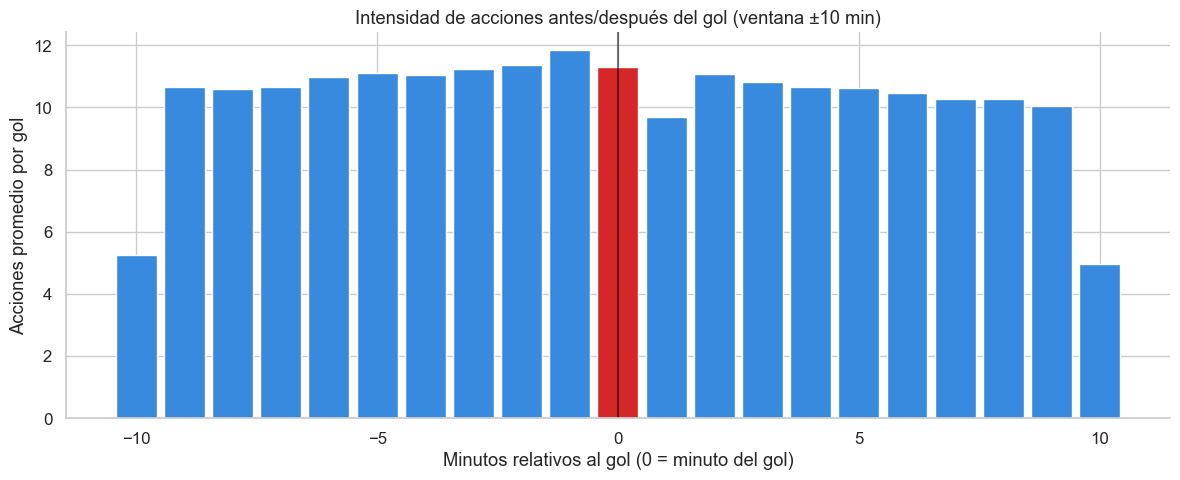

In [64]:
# 5. Patrón de actividad antes/después del gol
#    Para cada gol, tomamos una ventana de ±10 minutos alrededor del minuto del gol
#    y contamos acciones de ambos equipos en esa ventana, relativas al momento del gol (t=0)

VENTANA = 10  # minutos antes/después

pre_post_events = []

for _, goal in goals.iterrows():
    game_id = goal['game_id']
    goal_minute = goal['minute']

    game_actions = df_actions[
        (df_actions['game_id'] == game_id) &
        (df_actions['minute'] >= goal_minute - VENTANA) &
        (df_actions['minute'] <= goal_minute + VENTANA)
    ].copy()

    game_actions['minuto_relativo'] = (game_actions['minute'] - goal_minute).round().astype(int)
    pre_post_events.append(game_actions['minuto_relativo'])

minutos_relativos = pd.concat(pre_post_events)

# Densidad de acciones por minuto relativo al gol (t=0 = minuto del gol)
intensity_around_goal = minutos_relativos.value_counts().sort_index() / len(goals)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    intensity_around_goal.index, intensity_around_goal.values,
    color=['#d62728' if x == 0 else '#378ADD' for x in intensity_around_goal.index],
    width=0.85
)
ax.axvline(0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('Minutos relativos al gol (0 = minuto del gol)')
ax.set_ylabel('Acciones promedio por gol')
ax.set_title(f'Intensidad de acciones antes/después del gol (ventana ±{VENTANA} min)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Ejercicio 3 — Feature engineering avanzado

Implementamos tres features contextuales sobre `df_actions` (formato SPADL):

- **`shot_zone`** — zona desde donde se realizó el tiro: 3 carriles × dentro/fuera del área.
- **`pressing_intensity`** — nº de duelos (`take_on` + `tackle`) en los últimos 30 segundos.
- **`build_up_length`** — nº de pases consecutivos del mismo equipo previos a un tiro.

> **Nota de coordenadas — corregida el 2026-09-03.** La versión anterior de esta nota decía
> que `start_x` y `start_y` estaban "en escala 0-100". Es falso: `fix_actions` convierte las
> coordenadas a **metros** sobre un campo de **105 × 68**. Los umbrales originales
> (`y` entre 33,33 y 66,67 para el carril central, `BOX_X = 83` para el área) estaban
> calculados sobre una escala que a esa altura del pipeline ya no existía. El síntoma era
> visible en la salida: la banda derecha quedaba reducida a una franja de 1,33 m y capturaba
> **4 tiros de 25.236**, con `Derecha_Area` en cero.

> **Segunda corrección.** `time_seconds` **reinicia en cada período** (el 2T arranca en
> ~0,8 s). `pressing_intensity` y `build_up_length` agrupaban solo por `game_id`, así que
> las acciones del segundo tiempo se intercalaban con las del primero: la ventana de 30 s
> mezclaba mitades y las secuencias de pases cruzaban el entretiempo. Ahora se agrupa por
> `(game_id, period_id)`.

El orden cronológico se fija **una sola vez**, en la primera celda del ejercicio y antes de
construir cualquier máscara booleana. Reordenar el DataFrame después invalida en silencio
cualquier máscara armada sobre el índice anterior.


In [65]:
# ===== FEATURE 1: shot_zone =====
# ATENCION A LA ESCALA: despues de fix_actions las coordenadas SPADL estan en METROS
# sobre un campo de 105 x 68, no en la escala 0-100 de Wyscout. Los umbrales de abajo
# usan metros, igual que las features de la seccion 4 (in_box, last_third).
#
#   - Profundidad: el area grande empieza a 16,5 m del arco  ->  x >= 88.5
#   - Amplitud:    tres carriles de 68/3 = 22,67 m           ->  cortes en 22.67 y 45.33
#
# Convencion de lados: en el marco SPADL el ataque va hacia x=105; tomamos y alto como
# banda izquierda del equipo atacante e y bajo como derecha. Cual etiqueta va de cada
# lado no cambia el analisis mientras sea consistente: el control de que la escala esta
# bien es que ambas bandas queden aproximadamente simetricas.

LARGO, ANCHO = 105.0, 68.0
BOX_X   = LARGO - 16.5        # 88.5 — linea del area grande
CARRIL  = ANCHO / 3           # 22.67 — ancho de cada carril

# df_ltr ya viene orientado al equipo que ejecuta y ordenado cronologicamente desde la
# seccion 4. No se reordena aca: hacerlo despues de crear una mascara booleana la
# desalinearia en silencio.

es_tiro = df_ltr['type_name'] == 'shot'
x = df_ltr['start_x']
y = df_ltr['start_y']

lateral = np.where(y >= 2 * CARRIL, 'Izquierda',
          np.where(y >= CARRIL,     'Centro', 'Derecha'))
profundidad = np.where(x >= BOX_X, 'Area', 'FueraArea')

# Se construyen como Series con el indice de df_ltr: armarlas con pd.Series(array)
# generaria un RangeIndex nuevo y el .where() de abajo desalinearia las filas.
zona = pd.Series(lateral, index=df_ltr.index) + '_' + pd.Series(profundidad, index=df_ltr.index)
df_ltr['shot_zone'] = zona.where(es_tiro)

conteo = df_ltr.loc[es_tiro, 'shot_zone'].value_counts()
print('=== Distribucion de shot_zone (solo tiros) ===')
print(conteo.to_string())
print(f'\nTotal de tiros: {es_tiro.sum():,}')

# Control de simetria: si la escala fuera incorrecta, una banda quedaria casi vacia.
izq = conteo.filter(like='Izquierda').sum()
der = conteo.filter(like='Derecha').sum()
print(f'\nControl de simetria izquierda/derecha: {izq:,} vs {der:,} '
      f'(desvio {abs(izq-der)/max(izq,der)*100:.1f}%)')


=== Distribucion de shot_zone (solo tiros) ===
shot_zone
Centro_Area            11478
Centro_FueraArea        6954
Izquierda_Area          1957
Izquierda_FueraArea     1793
Derecha_Area            1565
Derecha_FueraArea       1489

Total de tiros: 25,236

Control de simetria izquierda/derecha: 3,750 vs 3,054 (desvio 18.6%)


In [66]:
# ===== FEATURE 2: pressing_intensity =====
# Numero de duelos (take_on + tackle) en los ultimos 30 segundos del mismo partido,
# sin importar el equipo: el pressing se mide por la densidad de duelos del entorno.
#
# IMPORTANTE: time_seconds REINICIA en cada periodo (el 2T arranca en ~0 s), asi que hay
# que agrupar por (game_id, period_id). Agrupando solo por partido, los eventos del
# segundo tiempo se intercalan con los del primero y la ventana de 30 s mezcla mitades.

TIPOS_DUELO = {'take_on', 'tackle'}
VENTANA_SEG = 30.0

# El orden cronologico ya quedo fijado en la celda de shot_zone.
def _pressing_intensity(g):
    t = g['time_seconds'].values
    duelos = np.sort(t[g['type_name'].isin(TIPOS_DUELO).values])
    if duelos.size == 0:
        return pd.Series(np.zeros(len(g), dtype=int), index=g.index)
    hasta = np.searchsorted(duelos, t, side='left')                 # duelos con tiempo <= t
    desde = np.searchsorted(duelos, t - VENTANA_SEG, side='right')  # duelos con tiempo > t-30
    return pd.Series(hasta - desde, index=g.index)

partes = [_pressing_intensity(g) for _, g in
          df_ltr.groupby(['game_id', 'period_id'], sort=False)]
df_ltr['pressing_intensity'] = pd.concat(partes).sort_index()

print('=== Resumen de pressing_intensity ===')
print(df_ltr['pressing_intensity'].describe().to_string())
print(f"\nAcciones con al menos un duelo reciente: "
      f"{(df_ltr['pressing_intensity'] > 0).mean()*100:.1f}%")
print('\nPartidos con mayor densidad media de duelos/30s:')
print(df_ltr.groupby('game_id')['pressing_intensity'].mean()
      .sort_values(ascending=False).head().round(3).to_string())


=== Resumen de pressing_intensity ===
count   1204377.0000
mean          0.0527
std           0.2393
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max           5.0000

Acciones con al menos un duelo reciente: 4.9%

Partidos con mayor densidad media de duelos/30s:
game_id
2576230   0.1850
2499789   0.1750
2576217   0.1490
2565595   0.1370
2565800   0.1300


In [67]:
# ===== FEATURE 3: build_up_length =====
# Numero de PASES consecutivos del mismo equipo que preceden a un tiro.
#
# Decision de diseno: la conduccion (dribble) NO corta la cadena, pero tampoco suma.
# Un jugador que recibe un pase, conduce cinco metros y remata tuvo construccion previa;
# contarlo como 0 seria incorrecto. En este dataset la decision pesa: 7.439 de los 25.236
# tiros (29,5%) estan precedidos por un dribble del mismo equipo. Con la definicion
# estricta la mediana da 1 y el 45,4% de los tiros quedan en cero; permitiendo dribbles
# la mediana da 3 y los ceros bajan al 20%, que corresponden a rematar tras recuperacion,
# rebote o segunda jugada.
#
# Nota: esta decision no existia antes de corregir el pipeline. Con solo 5.067 dribbles
# en el dataset original la eleccion era irrelevante; con 111.051 cambia el resultado.
#
# Se agrupa por (game_id, period_id) porque time_seconds reinicia en cada periodo.

CADENA = ['pass', 'dribble']   # acciones que mantienen viva la posesion

def _build_up_length(g):
    g = g.sort_values('time_seconds')
    tipo   = g['type_name'].values
    equipo = g['team_id'].values

    mismo_equipo = np.r_[False, equipo[1:] == equipo[:-1]]
    # la cadena sigue viva si la accion anterior mantuvo la posesion del mismo equipo
    sigue    = np.r_[False, np.isin(tipo[:-1], CADENA)] & mismo_equipo
    # ...pero solo los pases se cuentan
    es_pase  = np.r_[False, tipo[:-1] == 'pass'] & mismo_equipo

    s = pd.Series(sigue, index=g.index)
    bloques = (~s).cumsum()                       # cada corte de cadena abre un bloque
    conteo = pd.Series(es_pase, index=g.index).groupby(bloques).cumsum()

    return conteo.where(tipo == 'shot', 0).astype(int)

partes = [_build_up_length(g) for _, g in
          df_ltr.groupby(['game_id', 'period_id'], sort=False)]
df_ltr['build_up_length'] = pd.concat(partes).sort_index()

tiros = df_ltr[df_ltr['type_name'] == 'shot']
print('=== build_up_length (solo tiros) ===')
print(tiros['build_up_length'].describe().to_string())
print('\nTiros por numero de pases previos:')
print(tiros['build_up_length'].value_counts().sort_index().head(12).to_string())
print(f"\nTiros sin construccion previa: {(tiros['build_up_length'] == 0).mean()*100:.1f}%  "
      f"(recuperacion, rebote o segunda jugada)")


=== build_up_length (solo tiros) ===
count   25236.0000
mean        4.7426
std         5.4399
min         0.0000
25%         1.0000
50%         3.0000
75%         7.0000
max        87.0000

Tiros por numero de pases previos:
build_up_length
0     5045
1     3079
2     2984
3     2597
4     2041
5     1657
6     1336
7     1079
8      912
9      732
10     615
11     499

Tiros sin construccion previa: 20.0%  (recuperacion, rebote o segunda jugada)


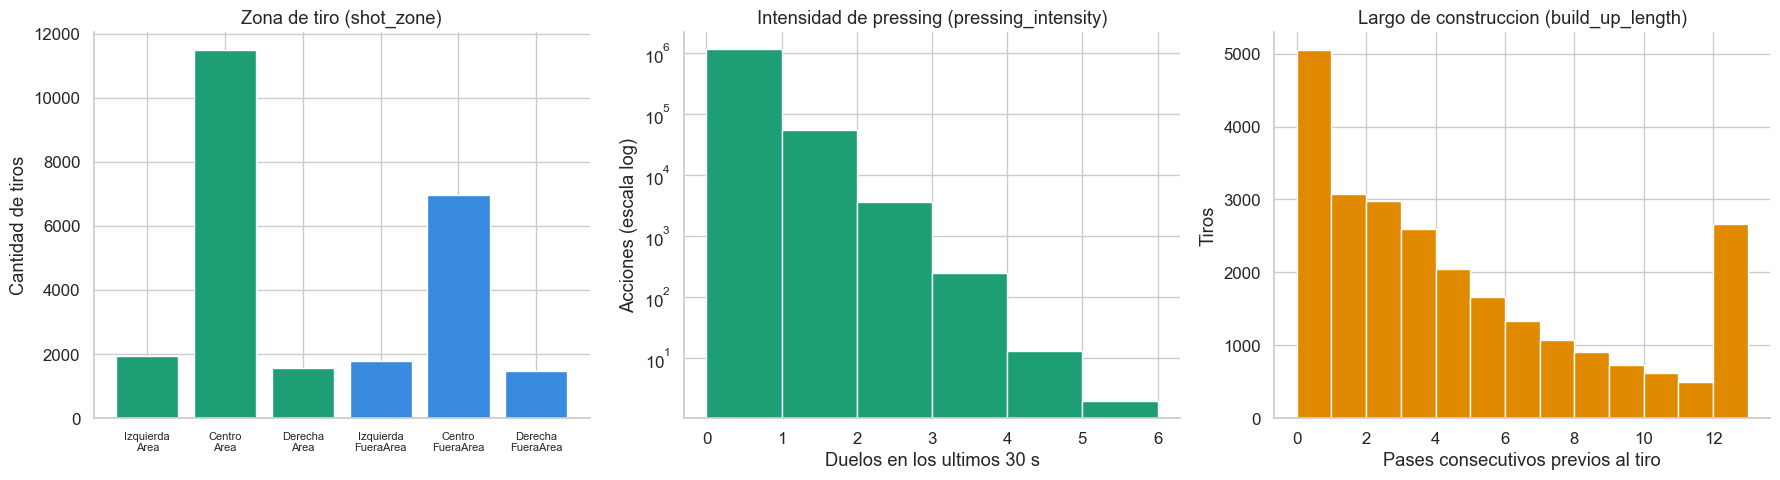

=== Controles ===
Rango de start_x: [0.0, 105.0]  (esperado 0-105, metros)
Rango de start_y: [0.0, 68.0]  (esperado 0-68, metros)

Tiros dentro del area: 59.4%
Columnas nuevas en df_ltr: ['shot_zone', 'pressing_intensity', 'build_up_length']


In [68]:
# ===== Validacion y visualizacion de las features =====
# Mascaras recalculadas sobre el df actual, no heredadas de celdas anteriores.
es_tiro = df_ltr['type_name'] == 'shot'
tiros = df_ltr[es_tiro]

ZONAS = ['Izquierda_Area', 'Centro_Area', 'Derecha_Area',
         'Izquierda_FueraArea', 'Centro_FueraArea', 'Derecha_FueraArea']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) shot_zone
conteo_zonas = df_ltr.loc[es_tiro, 'shot_zone'].value_counts().reindex(ZONAS).fillna(0)
colores = ['#1D9E75' if 'Area' == z.split('_')[1] else '#378ADD' for z in ZONAS]
axes[0].bar(range(len(ZONAS)), conteo_zonas.values, color=colores)
axes[0].set_xticks(range(len(ZONAS)))
axes[0].set_xticklabels([z.replace('_', '\n') for z in ZONAS], fontsize=8)
axes[0].set_ylabel('Cantidad de tiros')
axes[0].set_title('Zona de tiro (shot_zone)')
axes[0].spines[['top', 'right']].set_visible(False)

# (b) pressing_intensity
tope = int(df_ltr['pressing_intensity'].max())
axes[1].hist(df_ltr['pressing_intensity'], bins=range(0, tope + 2),
             color='#1D9E75', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_xlabel('Duelos en los ultimos 30 s')
axes[1].set_ylabel('Acciones (escala log)')
axes[1].set_title('Intensidad de pressing (pressing_intensity)')
axes[1].spines[['top', 'right']].set_visible(False)

# (c) build_up_length
axes[2].hist(tiros['build_up_length'].clip(0, 12), bins=range(0, 14),
             color='#E18A00', edgecolor='white')
axes[2].set_xlabel('Pases consecutivos previos al tiro')
axes[2].set_ylabel('Tiros')
axes[2].set_title('Largo de construccion (build_up_length)')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# --- Controles de sanidad de la escala de coordenadas ---
print('=== Controles ===')
print(f"Rango de start_x: [{df_ltr['start_x'].min():.1f}, {df_ltr['start_x'].max():.1f}]  "
      f"(esperado 0-105, metros)")
print(f"Rango de start_y: [{df_ltr['start_y'].min():.1f}, {df_ltr['start_y'].max():.1f}]  "
      f"(esperado 0-68, metros)")
print(f"\nTiros dentro del area: {(df_ltr.loc[es_tiro, 'start_x'] >= BOX_X).mean()*100:.1f}%")
print('Columnas nuevas en df_ltr:',
      [c for c in ['shot_zone', 'pressing_intensity', 'build_up_length'] if c in df_ltr.columns])


In [69]:
# ===== Numeros que respaldan las conclusiones del ejercicio =====
# Las conclusiones de abajo citan tasas de exito por zona y por largo de construccion.
# Se calculan aca para que sean verificables y no queden como cifras escritas a mano.

tiros = df_ltr[df_ltr['type_name'] == 'shot'].copy()
tiros['exito'] = tiros['result_name'] == 'success'

print('=== Tasa de exito registrada por zona de tiro ===')
print('(OJO: es la tasa de result_name == "success", que segun la Decision 6 es heuristica')
print(' en los tiros. Interpretable el ORDEN relativo, no el nivel absoluto.)\n')
z = tiros.groupby('shot_zone', observed=True).agg(tiros=('exito', 'size'), exitos=('exito', 'sum'))
z['tasa_%'] = (z['exitos'] / z['tiros'] * 100).round(1)
print(z.sort_values('tasa_%', ascending=False).to_string())

print('\n=== Tasa de exito por largo de construccion ===')
tiros['tramo'] = pd.cut(tiros['build_up_length'], [-1, 0, 2, 5, 10, 10_000],
                        labels=['0 (recuperacion)', '1-2', '3-5', '6-10', '11+'])
b = tiros.groupby('tramo', observed=True).agg(tiros=('exito', 'size'), exitos=('exito', 'sum'))
b['% del total'] = (b['tiros'] / len(tiros) * 100).round(1)
b['tasa_%'] = (b['exitos'] / b['tiros'] * 100).round(1)
print(b.to_string())

print('\n=== Control: pressing_intensity vs proporcion de acciones disputadas ===')
disputada = df_ltr['type_name'].isin(['tackle', 'take_on', 'interception'])
print(disputada.groupby(df_ltr['pressing_intensity'].clip(0, 3))
      .mean().mul(100).round(1).rename('% acciones disputadas').to_string())

print('\n=== Por que los dribbles no cortan la cadena de build_up ===')
previa = df_ltr['type_name'].shift(1)
mismo_equipo = df_ltr['team_id'].shift(1) == df_ltr['team_id']
es_tiro_ = df_ltr['type_name'] == 'shot'
conteo_previa = previa[es_tiro_ & mismo_equipo].value_counts()
print('Accion inmediatamente anterior a cada tiro (mismo equipo):')
print(conteo_previa.head(4).to_string())
n_dribble = int(conteo_previa.get('dribble', 0))
print(f"\nTiros precedidos por un dribble del mismo equipo: {n_dribble:,} "
      f"({n_dribble/len(tiros)*100:.1f}% de los tiros).")
print('Con la definicion estricta (solo pases mantienen la cadena) esos tiros quedarian')
print('en build_up_length = 0.')

# Comparacion explicita de las dos definiciones
def _largo(g, cadena):
    g = g.sort_values('time_seconds')
    tipo, equipo = g['type_name'].values, g['team_id'].values
    mismo = np.r_[False, equipo[1:] == equipo[:-1]]
    sigue = np.r_[False, np.isin(tipo[:-1], cadena)] & mismo
    pase  = np.r_[False, tipo[:-1] == 'pass'] & mismo
    s = pd.Series(sigue, index=g.index)
    return pd.Series(pase, index=g.index).groupby((~s).cumsum()).cumsum().where(tipo == 'shot', 0)

for etiqueta, cadena in [('estricta (solo pases)', ['pass']),
                         ('elegida (pases + dribbles)', ['pass', 'dribble'])]:
    r = pd.concat([_largo(g, cadena) for _, g in
                   df_ltr.groupby(['game_id', 'period_id'], sort=False)]).sort_index()
    t = r[es_tiro_]
    print(f"  {etiqueta:28s} mediana={t.median():.0f}  media={t.mean():.2f}  "
          f"ceros={(t == 0).mean()*100:.1f}%")


=== Tasa de exito registrada por zona de tiro ===
(OJO: es la tasa de result_name == "success", que segun la Decision 6 es heuristica
 en los tiros. Interpretable el ORDEN relativo, no el nivel absoluto.)

                     tiros  exitos  tasa_%
shot_zone                                 
Centro_Area          11478    4982 43.4000
Derecha_Area          1565     629 40.2000
Izquierda_Area        1957     713 36.4000
Centro_FueraArea      6954    1836 26.4000
Izquierda_FueraArea   1793     473 26.4000
Derecha_FueraArea     1489     384 25.8000

=== Tasa de exito por largo de construccion ===
                  tiros  exitos  % del total  tasa_%
tramo                                               
0 (recuperacion)   5045    1739      20.0000 34.5000
1-2                6063    2253      24.0000 37.2000
3-5                6295    2265      24.9000 36.0000
6-10               4674    1692      18.5000 36.2000
11+                3159    1068      12.5000 33.8000

=== Control: pressing_intensi

  estricta (solo pases)        mediana=1  media=1.80  ceros=45.4%


  elegida (pases + dribbles)   mediana=3  media=4.74  ceros=20.0%


**Conclusiones del Ejercicio 3**

**`shot_zone`** — el 59,4% de los tiros se toma dentro del área, un valor coherente con lo
que se observa en el fútbol profesional y el primer indicio de que la escala quedó bien.
La distribución:

| Zona | Tiros | Tasa de éxito registrada |
|---|---|---|
| Centro_Area | 11.478 | 43,4% |
| Centro_FueraArea | 6.954 | 26,4% |
| Izquierda_Area | 1.957 | 36,4% |
| Izquierda_FueraArea | 1.793 | 26,4% |
| Derecha_Area | 1.565 | 40,2% |
| Derecha_FueraArea | 1.489 | 25,8% |

El gradiente por profundidad es limpio: las tres zonas de área quedan entre 36% y 43%, y
las tres de fuera del área entre 25,8% y 26,4%. Es exactamente lo que predice la teoría de
xG, y funciona como validación de la feature.

*Advertencia sobre esos porcentajes:* la columna es la tasa de `result_name == 'success'`,
que según la Decisión 6 es heurística en los tiros y **no equivale a la tasa de conversión
real** — el nivel absoluto está inflado. Lo interpretable es el **orden relativo** entre
zonas, no el valor.

Sobre la asimetría izquierda/derecha (3.750 contra 3.054, un 18,6%): es un desvío real y no
un artefacto de escala — si la escala estuviera mal, una banda quedaría casi vacía, como
pasaba antes. Se corresponde con el patrón conocido de zurdos y diestros perfilándose desde
una banda para rematar al centro. Queda como observación, no como conclusión: verificarlo
exigiría cruzar con la pierna hábil de cada jugador.

**`pressing_intensity`** — el 95,1% de las acciones ocurre sin ningún duelo en los 30
segundos previos, con un máximo de 5. La distribución es de cola muy larga, así que la
feature no sirve como variable continua sino como identificador de fases disputadas. Chequeo
de que mide lo que dice medir: la proporción de acciones que son duelo o intercepción sube
de forma monótona con el valor de la feature (4,4% → 4,6% → 4,9% → 7,3% para 0, 1, 2 y 3+
duelos recientes).

**`build_up_length`** — mediana de 3 pases, media de 4,74, máximo de 87. El 20% de los tiros
no tiene construcción previa: son remates tras recuperación, rebote o segunda jugada.

La decisión de diseño acá no es menor. Un dribble en SPADL es una conducción del mismo
jugador, así que **no corta la posesión pero tampoco es un pase**: la cadena sigue viva y no
suma. Con la definición estricta —cualquier acción que no sea pase corta la cadena— la
mediana baja a 1 y el 45,4% de los tiros quedan en cero, porque 7.439 tiros (29,5%) están
precedidos por un dribble.

Y esa decisión **no existía antes de corregir el pipeline**: con los 5.067 dribbles del
dataset original la elección era irrelevante; con los 111.051 actuales cambia la mediana de
1 a 3. Es un ejemplo concreto de cómo un error de curación aguas arriba no solo distorsiona
los números, sino que oculta las decisiones metodológicas que habría que estar tomando.

**Un resultado negativo que vale la pena reportar:** el largo de la construcción **no mejora
la calidad del remate**. Agrupando los tiros por cantidad de pases previos, la tasa de éxito
registrada se mantiene plana entre 33,8% y 37,2%, sin tendencia:

| Pases previos | Tiros | % del total | Tasa de éxito |
|---|---|---|---|
| 0 (recuperación) | 5.045 | 20,0% | 34,5% |
| 1-2 | 6.063 | 24,0% | 37,2% |
| 3-5 | 6.295 | 24,9% | 36,0% |
| 6-10 | 4.674 | 18,5% | 36,2% |
| 11+ | 3.159 | 12,5% | 33,8% |

Con la misma advertencia sobre `result_id`: lo interpretable es la **ausencia de tendencia**,
no el nivel. Las jugadas elaboradas no terminan en mejores ocasiones que las de transición
rápida, al menos con esta medida. Es una hipótesis a testear en serio en el P3, donde xG y
VAEP dan una medida de calidad de ocasión que no depende de `result_id`.

*Decisión de curación asociada:* las tres features se calculan sobre coordenadas en metros y
con el orden cronológico respetando los períodos. No introducen NaN salvo `shot_zone`, que es
NaN por diseño en las acciones que no son tiros.



### Ejercicio 3 — Feature engineering avanzado
Implementá las siguientes features adicionales:
- `shot_zone`: zona del área desde donde se realizó el tiro (6 zonas estándar)
- `pressing_intensity`: número de duelos en los últimos 30 segundos
- `build_up_length`: longitud de la secuencia de pases antes de un tiro

### Ejercicio 4 — Sesgo posicional
Analizá si el número de acciones en SPADL está sesgado por posición.
¿Los delanteros tienen más acciones en el último tercio? ¿Los mediocampistas hacen más pases?
Graficá boxplots de las principales métricas por posición.

### Ejercicio 5 — Decisiones de curación
Basándote en el análisis anterior, documentá en un reporte las 5 decisiones más importantes
de curación para este dataset. Para cada decisión: ¿qué problema resolvió? ¿cuántos registros
afectó? ¿qué alternativas consideraste?

---
### **Entregable 4/9/26**: Notebook con EDA completo + reporte de decisiones de curación. PPT con donde se muestren los principales hallazgos encontrados en esos dos TPs.

---

## Ejercicio 4 — Sesgo posicional

> Analizá si el número de acciones en SPADL está sesgado por posición.
> ¿Los delanteros tienen más acciones en el último tercio? ¿Los mediocampistas hacen más pases?
> Graficá boxplots de las principales métricas por posición.

**Enfoque.** Separamos dos tipos de sesgo que suelen confundirse:

- **Sesgo de volumen** — *cuántas* acciones registra un jugador por 90 minutos. Responde a
  cuánto participa del juego.
- **Sesgo de composición** — *qué porción* del repertorio propio de cada jugador es de un
  tipo o está en una zona. Responde a cómo participa, y es independiente del volumen.

La distinción importa porque la normalización por 90 minutos de la sección 5 corrige el
primero pero no toca el segundo. Si los dos sesgos apuntan en la misma dirección, normalizar
por minutos alcanza; si apuntan en direcciones distintas, normalizar por minutos esconde el
problema en vez de resolverlo. Este ejercicio es la verificación empírica de que la
normalización posicional en dos etapas que propone la sección 5 hace falta.

**Base de análisis:** 1.221 jugadores con al menos 450 minutos, sobre las tres ligas.
Las métricas por 90' son marcadamente asimétricas y no cumplen el supuesto de normalidad
del ANOVA, así que usamos **Kruskal-Wallis**, su alternativa no paramétrica: trabaja sobre
rangos en vez de valores, contrasta si los grupos provienen de la misma distribución y es
resistente a outliers. Las comparaciones de a pares aplican el mismo test sobre dos grupos.

Reportamos además del p-valor una **medida del tamaño del efecto**. Con n=1.221 casi
cualquier diferencia da estadísticamente significativa, así que el p-valor solo no dice
nada sobre la magnitud: usamos ε² (0 a 1, qué proporción de la variabilidad explica la
posición) y el delta de Cliff (−1 a 1, cuánto más probable es que un jugador de un grupo
supere a uno del otro). Esta última parte excede lo visto en clase; se incluye porque sin
ella no se puede distinguir "no dio significativo" de "los dos grupos son equivalentes",
que es justamente el hallazgo central de la pregunta 3.


In [70]:
# ===== Base jugador-nivel: acciones, minutos reales y posicion =====
# Nota metodologica: la seccion 5 estima los minutos como `partidos * 75`. Aca usamos
# los minutos REALES, que ya estan calculados en datos_spadl["player_games"]
# (wyscout.py:175 los deriva de las alineaciones y las sustituciones). Ver el analisis
# de sesgo al final del ejercicio: la estimacion introduce un error que depende de la
# posicion, que es justamente el sesgo que este ejercicio busca medir.

ORDEN_POS = ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']
MIN_MINUTOS = 450   # mismo umbral que la seccion 5

# 1. Acciones por jugador
acc = df_spadl_fe[df_spadl_fe['player_id'] != 0].copy()

base = acc.groupby('player_id').agg(
    acciones          = ('type_id', 'size'),
    pases             = ('type_name', lambda s: (s == 'pass').sum()),
    tiros             = ('type_name', lambda s: (s == 'shot').sum()),
    gambetas          = ('type_name', lambda s: (s == 'take_on').sum()),
    tackles           = ('type_name', lambda s: (s == 'tackle').sum()),
    intercepciones    = ('type_name', lambda s: (s == 'interception').sum()),
    acc_ultimo_tercio = ('last_third', 'sum'),
    acc_area          = ('in_box', 'sum'),
).reset_index()

# 2. Minutos reales. 4 registros dan minutos negativos (sustituciones anotadas despues
#    del ultimo evento del 2T); se truncan a 0.
pg = datos_spadl['player_games'].copy()
pg['minutes_played'] = pg['minutes_played'].clip(lower=0)
minutos = pg.groupby('player_id').agg(
    minutos  = ('minutes_played', 'sum'),
    partidos = ('game_id', 'nunique'),
).reset_index()

# 3. Posicion principal
posiciones = df_players_filtrado[['wyId', 'main_position']].rename(columns={'wyId': 'player_id'})

df_pos = (base
          .merge(minutos, on='player_id', how='inner')
          .merge(posiciones, on='player_id', how='left'))
df_pos = df_pos[df_pos['main_position'].notna() & (df_pos['main_position'] != 'Unknown')]
df_pos = df_pos[df_pos['minutos'] >= MIN_MINUTOS].copy()

# 4. Normalizacion por 90 minutos (volumen) y por composicion (% del propio repertorio)
METRICAS = ['acciones', 'pases', 'tiros', 'gambetas', 'tackles',
            'intercepciones', 'acc_ultimo_tercio', 'acc_area']
for c in METRICAS:
    df_pos[f'{c}_p90'] = df_pos[c] / (df_pos['minutos'] / 90)

df_pos['pct_ultimo_tercio'] = df_pos['acc_ultimo_tercio'] / df_pos['acciones'] * 100
df_pos['pct_pases']         = df_pos['pases'] / df_pos['acciones'] * 100
df_pos['pct_area']          = df_pos['acc_area'] / df_pos['acciones'] * 100

df_pos['main_position'] = pd.Categorical(df_pos['main_position'],
                                         categories=ORDEN_POS, ordered=True)

print(f'Jugadores con >= {MIN_MINUTOS} minutos: {len(df_pos):,}')
print(df_pos['main_position'].value_counts().reindex(ORDEN_POS).to_string())
print(f"\nMinutos por jugador — mediana: {df_pos['minutos'].median():.0f} | "
      f"min: {df_pos['minutos'].min():.0f} | max: {df_pos['minutos'].max():.0f}")


Jugadores con >= 450 minutos: 1,221
main_position
Goalkeeper     87
Defender      445
Midfielder    434
Forward       255

Minutos por jugador — mediana: 1849 | min: 451 | max: 3612


In [71]:
# ===== Herramientas estadisticas =====
# Las metricas por 90' son fuertemente asimetricas y no normales, asi que no se cumple el
# supuesto del ANOVA. Usamos Kruskal-Wallis, la alternativa no parametrica al ANOVA de un
# factor: trabaja sobre rangos y no sobre los valores, evalua si los grupos provienen de la
# misma distribucion y es resistente a outliers.
#   H0: las medianas de todos los grupos son iguales.
#   H1: al menos una difiere.
# Para las comparaciones de a pares aplicamos el mismo test sobre dos grupos, que es su
# caso particular, en vez de introducir un test distinto.
#
# TAMANO DEL EFECTO. Reportamos ademas del p-valor una medida de magnitud, porque con
# n=1.221 practicamente cualquier diferencia da significativa y el p-valor no dice nada
# sobre que tan grande es. Usamos dos:
#   - epsilon^2, derivado del estadistico H, entre 0 y 1: que proporcion de la variabilidad
#     de la metrica explica la posicion.
#   - delta de Cliff, entre -1 y 1: la diferencia entre la probabilidad de que un jugador
#     del grupo A supere a uno del grupo B y la probabilidad inversa. delta = 0 significa
#     que elegir un jugador de cada grupo al azar es como tirar una moneda. Referencia de
#     lectura habitual: |d| ~ 0.15 chico, 0.33 medio, 0.47 grande.
# Esta parte excede lo visto en clase; se incluye porque sin ella un p-valor alto y un
# p-valor bajo con la misma diferencia real serian indistinguibles.

def kruskal_posicion(col, df=None, excluir_gk=False):
    """Kruskal-Wallis entre posiciones + epsilon^2 (tamano del efecto, 0 a 1)."""
    g = df_pos if df is None else df
    if excluir_gk:
        g = g[g['main_position'] != 'Goalkeeper']
    muestras = [x[col].dropna().values
                for _, x in g.groupby('main_position', observed=True) if len(x)]
    H, p = stats.kruskal(*muestras)
    n, k = sum(len(m) for m in muestras), len(muestras)
    eps2 = (H - k + 1) / (n - k)
    return H, p, eps2

def cliff_delta(x, y):
    """Delta de Cliff: P(x > y) - P(x < y), calculado por definicion."""
    x, y = np.asarray(x), np.asarray(y)
    mayores = np.sum(x[:, None] > y[None, :])
    menores = np.sum(x[:, None] < y[None, :])
    return (mayores - menores) / (len(x) * len(y))

def comparar(col, pos_a, pos_b):
    """Kruskal-Wallis sobre dos grupos + delta de Cliff."""
    x = df_pos.loc[df_pos['main_position'] == pos_a, col].dropna().values
    y = df_pos.loc[df_pos['main_position'] == pos_b, col].dropna().values
    H, p = stats.kruskal(x, y)
    # el p-valor va como texto: el display.float_format global ('{:.4f}') aplastaria
    # a 0.0000 cualquier valor por debajo de 1e-4, que es la mayoria de estos contrastes.
    return {'comparacion': f'{pos_a} vs {pos_b}', 'mediana_a': round(np.median(x), 2),
            'mediana_b': round(np.median(y), 2), 'p_valor': f'{p:.3g}',
            'cliff_delta': round(cliff_delta(x, y), 3)}

def tabla_comparaciones(col, pares):
    return pd.DataFrame([comparar(col, a, b) for a, b in pares])


# ===== Pregunta 1: el volumen de acciones, ¿esta sesgado por posicion? =====
print('=== Acciones por 90 minutos, por posicion ===')
print(df_pos.groupby('main_position', observed=True)['acciones_p90']
      .describe()[['count', '25%', '50%', '75%']].round(2).to_string())

H, p, eps2 = kruskal_posicion('acciones_p90')
print(f'\nKruskal-Wallis (4 posiciones): H={H:.1f}  p={p:.3g}  epsilon^2={eps2:.3f}')
H, p, eps2 = kruskal_posicion('acciones_p90', excluir_gk=True)
print(f'Sin arqueros (3 posiciones):  H={H:.1f}  p={p:.3g}  epsilon^2={eps2:.3f}')

print('\nComparaciones de a pares:')
print(tabla_comparaciones('acciones_p90',
      [('Midfielder', 'Defender'), ('Defender', 'Forward'), ('Midfielder', 'Forward')]).to_string(index=False))


=== Acciones por 90 minutos, por posicion ===
                 count     25%     50%     75%
main_position                                 
Goalkeeper     87.0000 16.4200 18.0800 21.9700
Defender      445.0000 40.4600 47.5100 57.4100
Midfielder    434.0000 42.6300 51.3400 61.2600
Forward       255.0000 25.8600 31.9700 38.7700

Kruskal-Wallis (4 posiciones): H=507.9  p=9.07e-110  epsilon^2=0.415
Sin arqueros (3 posiciones):  H=317.1  p=1.41e-69  epsilon^2=0.279

Comparaciones de a pares:
           comparacion  mediana_a  mediana_b  p_valor  cliff_delta
Midfielder vs Defender    51.3400    47.5100 0.000725       0.1320
   Defender vs Forward    47.5100    31.9700 2.32e-53       0.6980
 Midfielder vs Forward    51.3400    31.9700 2.99e-60       0.7460


In [72]:
# ===== Pregunta 2: ¿los delanteros tienen mas acciones en el ultimo tercio? =====
# Se mide de dos formas, porque responden preguntas distintas:
#   - volumen (p90): cuantas acciones ofensivas produce el jugador por 90'
#   - composicion (%): que porcion de SU repertorio ocurre en el ultimo tercio
# El ultimo tercio es start_x >= 70 sobre un campo SPADL de 105 m (mismo criterio
# que la feature `last_third` de la seccion 4).

print('=== Ultimo tercio: volumen vs composicion ===')
print(df_pos.groupby('main_position', observed=True)[
      ['acc_ultimo_tercio_p90', 'pct_ultimo_tercio', 'acc_area_p90', 'pct_area']
      ].median().round(2).to_string())

H, p, eps2 = kruskal_posicion('acc_ultimo_tercio_p90', excluir_gk=True)
print(f'\nVolumen p90   -> H={H:.1f}  p={p:.3g}  epsilon^2={eps2:.3f}')
H, p, eps2 = kruskal_posicion('pct_ultimo_tercio', excluir_gk=True)
print(f'Composicion % -> H={H:.1f}  p={p:.3g}  epsilon^2={eps2:.3f}')

print('\nVolumen (acciones en ultimo tercio por 90\'):')
print(tabla_comparaciones('acc_ultimo_tercio_p90',
      [('Forward', 'Midfielder'), ('Midfielder', 'Defender')]).to_string(index=False))
print('\nComposicion (% de las acciones del jugador):')
print(tabla_comparaciones('pct_ultimo_tercio',
      [('Forward', 'Midfielder'), ('Midfielder', 'Defender')]).to_string(index=False))


=== Ultimo tercio: volumen vs composicion ===
               acc_ultimo_tercio_p90  pct_ultimo_tercio  acc_area_p90  pct_area
main_position                                                                  
Goalkeeper                    0.2700             1.4000        0.1400    0.7500
Defender                      5.1700            10.1400        0.8700    1.7900
Midfielder                   14.9900            29.1900        1.6500    3.3200
Forward                      17.0800            54.6200        3.6200   11.2000

Volumen p90   -> H=378.5  p=6.39e-83  epsilon^2=0.333
Composicion % -> H=648.4  p=1.57e-141  epsilon^2=0.572

Volumen (acciones en ultimo tercio por 90'):
           comparacion  mediana_a  mediana_b  p_valor  cliff_delta
 Forward vs Midfielder    17.0800    14.9900 1.26e-06       0.2210
Midfielder vs Defender    14.9900     5.1700 2.88e-57       0.6220

Composicion (% de las acciones del jugador):
           comparacion  mediana_a  mediana_b  p_valor  cliff_delta
 For

In [73]:
# ===== Pregunta 3: ¿los mediocampistas hacen mas pases? =====
print('=== Pases: volumen vs composicion ===')
print(df_pos.groupby('main_position', observed=True)[['pases_p90', 'pct_pases']]
      .median().round(2).to_string())

H, p, eps2 = kruskal_posicion('pases_p90', excluir_gk=True)
print(f'\nVolumen p90   -> H={H:.1f}  p={p:.3g}  epsilon^2={eps2:.3f}')
H, p, eps2 = kruskal_posicion('pct_pases', excluir_gk=True)
print(f'Composicion % -> H={H:.1f}  p={p:.3g}  epsilon^2={eps2:.3f}')

print('\nVolumen (pases por 90\'):')
print(tabla_comparaciones('pases_p90',
      [('Midfielder', 'Defender'), ('Midfielder', 'Forward')]).to_string(index=False))
print('\nComposicion (% de las acciones del jugador que son pases):')
print(tabla_comparaciones('pct_pases',
      [('Defender', 'Midfielder'), ('Midfielder', 'Forward')]).to_string(index=False))


=== Pases: volumen vs composicion ===
               pases_p90  pct_pases
main_position                      
Goalkeeper       16.6200    91.7500
Defender         39.6100    84.2800
Midfielder       40.8000    80.4000
Forward          22.7500    70.7800

Volumen p90   -> H=365.4  p=4.52e-80  epsilon^2=0.321
Composicion % -> H=596.1  p=3.7e-130  epsilon^2=0.525

Volumen (pases por 90'):
           comparacion  mediana_a  mediana_b  p_valor  cliff_delta
Midfielder vs Defender    40.8000    39.6100     0.58       0.0220
 Midfielder vs Forward    40.8000    22.7500 5.44e-65       0.7760

Composicion (% de las acciones del jugador que son pases):
           comparacion  mediana_a  mediana_b  p_valor  cliff_delta
Defender vs Midfielder    84.2800    80.4000 1.19e-41       0.5270
 Midfielder vs Forward    80.4000    70.7800 3.21e-69       0.8020


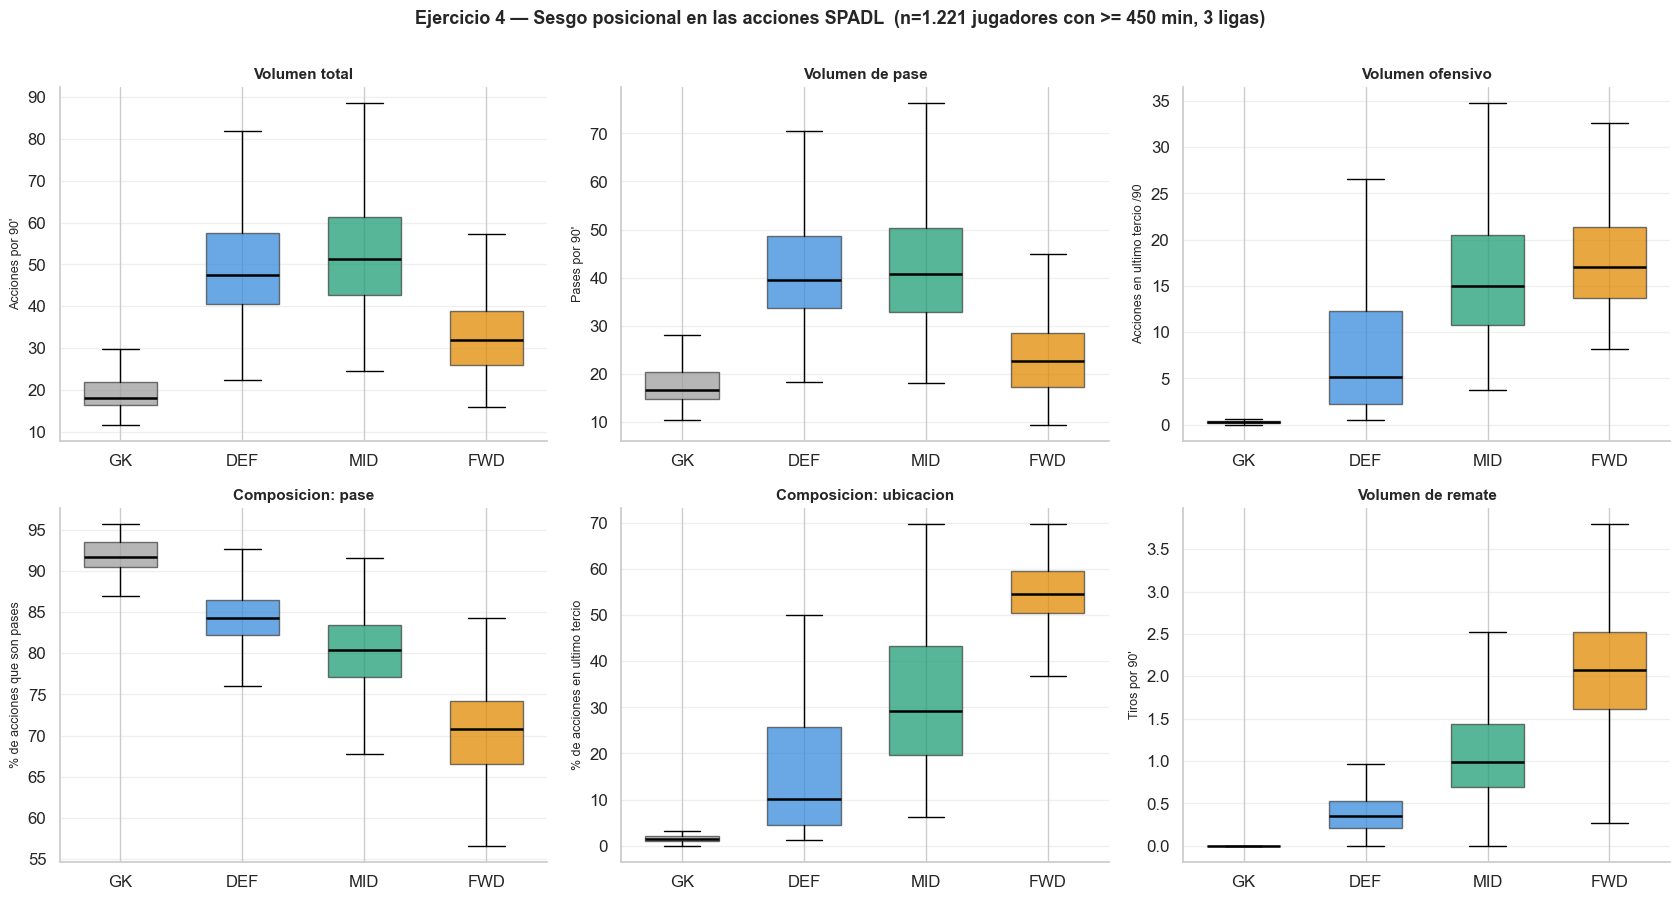

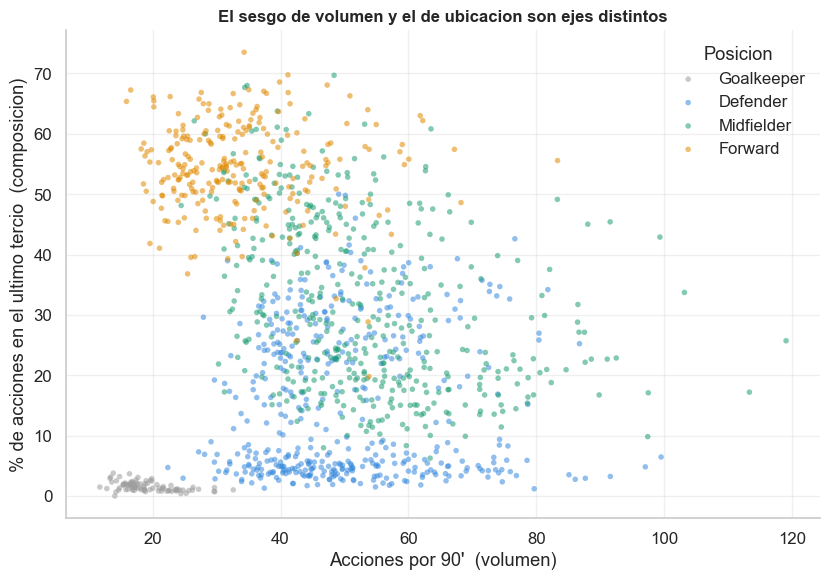

In [74]:
# ===== Boxplots de las metricas principales por posicion =====
COLOR_POS = {'Goalkeeper': '#9E9E9E', 'Defender': '#378ADD',
             'Midfielder': '#1D9E75', 'Forward': '#E18A00'}

paneles = [
    ('acciones_p90',          'Acciones por 90\'',            'Volumen total'),
    ('pases_p90',             'Pases por 90\'',               'Volumen de pase'),
    ('acc_ultimo_tercio_p90', 'Acciones en ultimo tercio /90', 'Volumen ofensivo'),
    ('pct_pases',             '% de acciones que son pases',  'Composicion: pase'),
    ('pct_ultimo_tercio',     '% de acciones en ultimo tercio', 'Composicion: ubicacion'),
    ('tiros_p90',             'Tiros por 90\'',               'Volumen de remate'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (col, etiqueta, titulo) in zip(axes.ravel(), paneles):
    datos = [df_pos.loc[df_pos['main_position'] == p, col].dropna().values for p in ORDEN_POS]
    bp = ax.boxplot(datos, patch_artist=True, showfliers=False, widths=0.6,
                    medianprops=dict(color='black', linewidth=1.8))
    for caja, p in zip(bp['boxes'], ORDEN_POS):
        caja.set_facecolor(COLOR_POS[p]); caja.set_alpha(0.75); caja.set_edgecolor('#444')
    ax.set_xticklabels(['GK', 'DEF', 'MID', 'FWD'])
    ax.set_ylabel(etiqueta, fontsize=9)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Ejercicio 4 — Sesgo posicional en las acciones SPADL  '
             '(n=1.221 jugadores con >= 450 min, 3 ligas)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Volumen vs composicion: el mismo jugador, los dos ejes
fig, ax = plt.subplots(figsize=(8.5, 6))
for p in ORDEN_POS:
    sub = df_pos[df_pos['main_position'] == p]
    ax.scatter(sub['acciones_p90'], sub['pct_ultimo_tercio'], s=16, alpha=0.55,
               color=COLOR_POS[p], label=p, edgecolors='none')
ax.set_xlabel('Acciones por 90\'  (volumen)')
ax.set_ylabel('% de acciones en el ultimo tercio  (composicion)')
ax.set_title('El sesgo de volumen y el de ubicacion son ejes distintos',
             fontsize=12, fontweight='bold')
ax.legend(title='Posicion', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [75]:
# ===== El sesgo que introduce la propia metrica de minutos =====
# La seccion 5 estima minutos como `partidos * 75`. Comparamos contra los minutos reales.
df_pos['minutos_estimados'] = df_pos['partidos'] * 75
df_pos['error_estimacion_pct'] = (df_pos['minutos_estimados'] - df_pos['minutos']) / df_pos['minutos'] * 100
df_pos['acciones_p90_estimado'] = df_pos['acciones'] / (df_pos['minutos_estimados'] / 90)

comparacion_min = df_pos.groupby('main_position', observed=True).agg(
    error_mediano_pct   = ('error_estimacion_pct', 'median'),
    acciones_p90_real   = ('acciones_p90', 'median'),
    acciones_p90_estim  = ('acciones_p90_estimado', 'median'),
).round(2)
comparacion_min['distorsion_pct'] = (
    (comparacion_min['acciones_p90_estim'] - comparacion_min['acciones_p90_real'])
    / comparacion_min['acciones_p90_real'] * 100).round(1)

print('=== Minutos reales vs estimados (partidos * 75) ===')
print(comparacion_min.to_string())
print('\nLa estimacion subestima los minutos de arqueros y defensores (juegan casi siempre')
print('los 90) y los sobreestima en delanteros (mas suplencias y reemplazos), asi que')
print('infla artificialmente el p90 de unos y lo deprime en otros.')

# ===== Consistencia entre las tres ligas =====
game_league = df_all[['matchId', 'league']].drop_duplicates().rename(columns={'matchId': 'game_id'})
liga_jugador = (df_spadl_fe[['player_id', 'game_id']]
                .merge(game_league, on='game_id', how='left')
                .groupby('player_id')['league']
                .agg(lambda s: s.value_counts().index[0]).rename('liga'))
df_pos_liga = df_pos.merge(liga_jugador, on='player_id', how='left')

print('\n=== ¿El patron se repite en las tres ligas? (medianas) ===')
for metrica in ['pct_ultimo_tercio', 'pct_pases', 'acciones_p90']:
    print(f'\n{metrica}:')
    print(df_pos_liga.pivot_table(index='liga', columns='main_position',
                                  values=metrica, aggfunc='median', observed=True)
          .reindex(columns=ORDEN_POS).round(1).to_string())


=== Minutos reales vs estimados (partidos * 75) ===
               error_mediano_pct  acciones_p90_real  acciones_p90_estim  distorsion_pct
main_position                                                                          
Goalkeeper              -19.9800            18.0800             22.6500         25.3000
Defender                -12.7100            47.5100             52.3600         10.2000
Midfielder                3.2700            51.3400             47.5000         -7.5000
Forward                  20.3500            31.9700             25.8600        -19.1000

La estimacion subestima los minutos de arqueros y defensores (juegan casi siempre
los 90) y los sobreestima en delanteros (mas suplencias y reemplazos), asi que
infla artificialmente el p90 de unos y lo deprime en otros.



=== ¿El patron se repite en las tres ligas? (medianas) ===

pct_ultimo_tercio:
main_position  Goalkeeper  Defender  Midfielder  Forward
liga                                                    
England            1.3000   13.7000     29.7000  56.3000
Italy              1.8000    8.8000     29.1000  53.8000
Spain              1.4000   10.8000     29.1000  53.0000

pct_pases:
main_position  Goalkeeper  Defender  Midfielder  Forward
liga                                                    
England           92.9000   84.1000     80.4000  70.0000
Italy             91.7000   84.9000     80.4000  70.8000
Spain             91.0000   83.6000     80.4000  71.5000

acciones_p90:
main_position  Goalkeeper  Defender  Midfielder  Forward
liga                                                    
England           18.1000   44.4000     50.7000  31.0000
Italy             19.2000   50.2000     52.0000  32.6000
Spain             17.1000   47.2000     50.3000  32.1000


### Conclusiones del Ejercicio 4

**1. Sí, hay sesgo posicional, y es grande.** Kruskal-Wallis sobre acciones por 90':
H=507,9, p≈9e-110, **ε²=0,415** — la posición explica el 41,5% de la varianza en volumen
de acciones. Excluyendo arqueros sigue siendo sustancial (ε²=0,279).

**2. Pero el sesgo no va en la dirección que sugería la hipótesis del práctico.** En la
sección 2.5 se planteó que *"los jugadores ofensivos tienen más eventos registrados"*.
Los datos dicen lo contrario en volumen:

| Posición | Acciones/90' (mediana) |
|---|---|
| Midfielder | 51,34 |
| Defender | 47,51 |
| **Forward** | **31,97** |
| Goalkeeper | 18,08 |

Los delanteros registran **un 38% menos de acciones** que los mediocampistas
(Cliff d=+0,746, efecto grande). La diferencia entre mediocampistas y defensores, en
cambio, es significativa pero chica (p=0,0007, d=+0,132): en volumen bruto, defensores y
mediocampistas son casi el mismo grupo.

La otra mitad de la hipótesis sí se confirma — los ofensivos registran más eventos cerca
del arco — pero eso es composición, no volumen. Son cosas distintas y conviene no
mezclarlas.

**3. ¿Los delanteros tienen más acciones en el último tercio? Sí, y es el efecto más
fuerte del ejercicio.**

| Posición | Acciones últ. tercio /90' | % del repertorio propio |
|---|---|---|
| Forward | 17,08 | **54,62%** |
| Midfielder | 14,99 | 29,19% |
| Defender | 5,17 | 10,14% |
| Goalkeeper | 0,27 | 1,40% |

Acá la distinción entre los dos ejes se ve nítida. En **volumen**, la ventaja del delantero
sobre el mediocampista es modesta: 17,08 contra 14,99 (d=+0,221, efecto chico) — el
mediocampista compensa jugando mucho más. En **composición**, la diferencia es enorme:
54,62% contra 29,19% (d=+0,823, ε²=0,572).

Traducido: el delantero no produce muchas más acciones ofensivas que el mediocampista;
produce **casi solo** acciones ofensivas. Un modelo entrenado sobre conteos crudos va a leer
esa concentración como si fuera volumen, y ahí está el sesgo.

**4. ¿Los mediocampistas hacen más pases? No.** Es la pregunta cuya respuesta intuitiva
falla:

| Posición | Pases/90' | % de sus acciones que son pases |
|---|---|---|
| Midfielder | 40,80 | 80,40% |
| Defender | 39,61 | **84,28%** |
| Forward | 22,75 | 70,78% |
| Goalkeeper | 16,62 | 91,75% |

- En **volumen**, mediocampistas y defensores son **estadísticamente indistinguibles**:
  40,80 contra 39,61, **p=0,58**, Cliff d=+0,022. Es el único contraste del ejercicio que
  no da significativo, y con n=879 eso es una afirmación fuerte, no falta de potencia.
- En **composición**, los **defensores pasan proporcionalmente más** que los mediocampistas:
  84,28% contra 80,40% (p≈1e-41, d=+0,527).

La lectura futbolística: el mediocampista tiene un repertorio más variado — pasa parecido
al defensor pero además tacklea, intercepta, gambetea y remata. El defensor hace menos
cosas distintas y casi todo lo que hace es pasar. La creencia de que "el mediocampista es
el que más pasa" confunde volumen con protagonismo.

**5. El propio criterio de medición introduce sesgo posicional.** La sección 5 estima los
minutos como `partidos × 75`, pero `datos_spadl["player_games"]` tiene los minutos reales.
El error de esa estimación **depende de la posición**:

| Posición | Error mediano de la estimación | Distorsión en acciones/90' |
|---|---|---|
| Goalkeeper | −19,98% | **+25,3%** |
| Defender | −12,71% | +10,2% |
| Midfielder | +3,27% | −7,5% |
| Forward | +20,35% | **−19,1%** |

Arqueros y defensores juegan casi siempre los 90, así que `× 75` les **subestima** los
minutos y les **infla** el p90. Los delanteros son los más sustituidos, así que les
sobreestima los minutos y les deprime el p90. El resultado es que la estimación
**amplifica artificialmente la brecha** que este ejercicio busca medir: exagera el volumen
de los defensivos y hunde el de los ofensivos, la distorsión en acciones/90' va de +25,3% en arqueros a −19,1% en delanteros, 44,4 puntos entre las dos puntas. Un sesgo de medición que se confunde con el fenómeno medido.

**6. El patrón es estable entre ligas.** Las medianas de las tres métricas reproducen el
mismo orden en England, Italy y Spain, con diferencias de pocos puntos. No es un artefacto
de una competición. La única variación apreciable: los defensores ingleses llegan al último
tercio bastante más (13,7% de sus acciones) que los italianos (8,8%), consistente con
estilos de juego distintos y no con un problema de datos.

---

**Decisión de curación asociada (aporta al Ejercicio 5):** para cualquier comparación entre
jugadores hay que usar los minutos reales de `player_games`, no `partidos × 75`, y hay que
normalizar **por posición**, no solo por tiempo. Normalizar únicamente por 90 minutos deja
intacto el sesgo de composición, que en este dataset es el más fuerte de los dos
(ε²=0,572 contra 0,333 en el último tercio; 0,525 contra 0,321 en pases). Los 4 registros
con minutos negativos que devuelve `get_player_games` se truncan a 0.


---

## Ejercicio 5 — Reporte de decisiones de curación

> Basándote en el análisis anterior, documentá en un reporte las 5 decisiones más
> importantes de curación para este dataset. Para cada decisión: ¿qué problema resolvió?
> ¿cuántos registros afectó? ¿qué alternativas consideraste?

**Criterio de selección.** Se priorizaron las decisiones por volumen de registros afectados
y por si comprometían conclusiones, no por dificultad técnica. Quedaron afuera del top 5
decisiones correctas pero de impacto acotado, que se listan igual al final para dejar
registro.

**Cómo se validaron los números.** Todas las cifras de "registros afectados" salen de correr
el pipeline dos veces sobre las tres ligas completas: una con el código original y otra con
las correcciones. La corrida original reproduce exactamente el resultado que tenía el
notebook antes de esta revisión, y los dos valores centrales son verificables sin correr
nada: están guardados en los outputs del notebook del commit `c6e3a0e`
(`print(df_actions.shape)` → `(1098393, 17)`, y `Casos donde faltan ambos: 991522`).
Los conteos por tipo de acción salen de re-ejecutar el pipeline original. La fila de orientación no cambia conteos:
cuenta las acciones cuyas features espaciales estaban invertidas.

| | Pipeline original | Pipeline corregido |
|---|---|---|
| Acciones totales | 1.098.393 | **1.204.377** |
| Acciones sin coordenada de destino | 991.522 (90,27%) | **0 (0,00%)** |
| Dribbles detectados | 5.067 | **111.051** |
| Acciones del visitante sin orientar en features espaciales | 583.436 (48,4%) | **0** |

Los otros siete tipos de acción mantienen exactamente el mismo conteo (`pass` 984.696,
`interception` 40.505, `foul` 29.097, `shot` 25.236, `tackle` 9.960, `take_on` 2.525,
`keeper_save` 1.307): las correcciones no inventan ni descartan eventos, solo recuperan
información que el pipeline estaba perdiendo.


In [76]:
# ===== Auditoria reproducible: los numeros que respaldan el reporte =====
# El enunciado pide, por cada decision, cuantos registros afecto. Esta celda recalcula
# esas cifras sobre el dataset ya curado en vez de dejarlas escritas a mano, para que
# el reporte se pueda re-verificar si cambian los datos o las ligas seleccionadas.

reporte_curacion = {}

# --- D1: colision de nombres end_x/end_y en la conversion SPADL ---
reporte_curacion['D1_acciones_totales']       = len(df_actions)
reporte_curacion['D1_end_x_nulos']            = int(df_actions['end_x'].isna().sum())
reporte_curacion['D1_dribbles_generados']     = int((df_actions['type_name'] == 'dribble').sum())

# --- D2: orientacion al equipo que ejecuta antes de las features espaciales ---
es_visitante = df_actions['team_id'] != df_actions['game_id'].map(home_por_partido)
reporte_curacion['D2_acciones_reorientadas']  = int(es_visitante.sum())
reporte_curacion['D2_pct_reorientadas']       = round(es_visitante.mean() * 100, 1)
# Control: en el marco fijo de SPADL los tiros de local y visitante van a arcos
# opuestos (correcto); ya orientados en df_ltr, ambos apuntan al mismo arco.
_t_fijo = df_actions[df_actions['type_name'] == 'shot']
_t_ltr  = df_ltr[df_ltr['type_name'] == 'shot']
_vis_ltr = df_ltr['team_id'] != df_ltr['game_id'].map(home_por_partido)
reporte_curacion['D2_fijo_tiros_x_local']     = round(_t_fijo.loc[~es_visitante.loc[_t_fijo.index], 'start_x'].median(), 1)
reporte_curacion['D2_fijo_tiros_x_visitante'] = round(_t_fijo.loc[es_visitante.loc[_t_fijo.index], 'start_x'].median(), 1)
reporte_curacion['D2_ltr_tiros_x_local']      = round(_t_ltr.loc[~_vis_ltr.loc[_t_ltr.index], 'start_x'].median(), 1)
reporte_curacion['D2_ltr_tiros_x_visitante']  = round(_t_ltr.loc[_vis_ltr.loc[_t_ltr.index], 'start_x'].median(), 1)

# --- D3: escala de coordenadas (metros, no 0-100) ---
reporte_curacion['D3_start_x_max']            = round(df_actions['start_x'].max(), 1)
reporte_curacion['D3_start_y_max']            = round(df_actions['start_y'].max(), 1)

# --- D4: minutos jugados reales vs estimados ---
_pg = datos_spadl['player_games']
reporte_curacion['D4_registros_player_games'] = len(_pg)
reporte_curacion['D4_minutos_negativos']      = int((_pg['minutes_played'] < 0).sum())

# --- D5: coordenadas fuera de rango en el dataset crudo ---
# df_all ya viene sin el registro fuera de rango (se elimino en la celda 26)
reporte_curacion['D5_eventos_crudos']         = len(df_all) + len(out_of_bounds)
reporte_curacion['D5_fuera_de_rango']         = len(out_of_bounds)

print('=== REPORTE DE CURACION — cifras verificadas ===')
for k, v in reporte_curacion.items():
    print(f'  {k:32s} {v:>12,}' if isinstance(v, int) else f'  {k:32s} {v:>12}')

print('\n--- Control de la orientacion del campo ---')
print(f"  marco fijo SPADL   -> local: {reporte_curacion['D2_fijo_tiros_x_local']} | "
      f"visitante: {reporte_curacion['D2_fijo_tiros_x_visitante']}   (opuestos: correcto)")
print(f"  orientado (df_ltr) -> local: {reporte_curacion['D2_ltr_tiros_x_local']} | "
      f"visitante: {reporte_curacion['D2_ltr_tiros_x_visitante']}   (iguales: listo para features)")

print('\n--- Cobertura de coordenadas de destino por tipo de accion ---')
print(df_actions.groupby('type_name')['end_x']
      .apply(lambda s: round(s.notna().mean() * 100, 1)).sort_values().to_string())


=== REPORTE DE CURACION — cifras verificadas ===
  D1_acciones_totales                 1,204,377
  D1_end_x_nulos                              0
  D1_dribbles_generados                 111,051
  D2_acciones_reorientadas              583,436
  D2_pct_reorientadas                      48.4
  D2_fijo_tiros_x_local                    91.4
  D2_fijo_tiros_x_visitante                13.7
  D2_ltr_tiros_x_local                     91.4
  D2_ltr_tiros_x_visitante                 91.4
  D3_start_x_max                          105.0
  D3_start_y_max                           68.0
  D4_registros_player_games              31,574
  D4_minutos_negativos                        4
  D5_eventos_crudos                   1,919,181
  D5_fuera_de_rango                           1

--- Control de la orientacion del campo ---
  marco fijo SPADL   -> local: 91.4 | visitante: 13.7   (opuestos: correcto)
  orientado (df_ltr) -> local: 91.4 | visitante: 91.4   (iguales: listo para features)

--- Cobertura de coor

### Decisión 1 — Colisión de nombres de columnas en la conversión a SPADL

**Problema.** El 90,27% de las acciones (991.522 de 1.098.393) quedaba sin coordenada de
destino: `pass` con 0,6% de cobertura, `tackle` y `take_on` con 0%. En el dataset Wyscout
crudo la cobertura es del 100% — verificado sobre 51.360 pases, todos con sus dos
posiciones.

**Causa.** La celda 21 crea las columnas `end_x`/`end_y` en `df_all` durante el EDA. Esos
nombres coinciden con los que genera `make_new_positions` dentro de `wyscout.py`, y el
`pd.merge` de la línea 340 los desambigua con sufijos: quedan `end_x_x`, `end_y_x`,
`end_x_y`, `end_y_y` y **ninguna columna `end_x`**. Pandas no emite warning: el merge con
sufijos es su comportamiento normal. La primera función que después le asigna un valor
(`create_shot_coordinates`) crea la columna de cero llena de NaN y solo completa las filas
que toca. Por eso sobreviven exactamente los tipos de acción que tienen función propia de
asignación de destino.

Ni el notebook ni `wyscout.py` están mal por separado. El error vive en la interacción, y
por eso resistió tres diagnósticos que buscaron la falla dentro de `wyscout.py`.

**Registros afectados.** 991.522 acciones recuperan su coordenada de destino. Como efecto
secundario, los dribbles pasan de 5.067 a 111.051 (**×21,9**): `add_dribbles` detecta las
conducciones comparando el `end_x` de una acción con el `start_x` de la siguiente, y sin
destino no podía generarlas. El dataset tenía el **95,4% de los dribbles faltantes**.

**Decisión.** Soltar `['x','y','end_x','end_y']` del DataFrame de eventos al armar
`events_dict` (celda 42). El EDA conserva sus columnas y la conversión recibe el DataFrame
limpio.

**Alternativas consideradas.**
1. *Join posterior entre `df_actions` y `df_all` por id de evento.* Descartada: los dribbles
   sintéticos que crea `add_dribbles` no tienen id de evento Wyscout al que unirse, así que
   el join dejaría afuera justamente las 105.984 acciones nuevas. Además no corrige la causa
   y hay que repetirlo en cada corrida.
2. *Modificar `make_position_vars` para devolver `None` cuando hay una sola posición.*
   Se implementó y se revirtió: partía de la premisa de que la mayoría de los pases tenían
   una sola posición, que es falsa (25 eventos de cada 100.000, todos fouls).
3. *Renombrar las columnas del EDA a `dest_x`/`dest_y`.* Funcionalmente equivalente. Se
   prefirió el `drop` porque hace explícita la frontera entre el EDA y la conversión, en vez
   de depender de que nadie vuelva a elegir un nombre que colisione.

---

### Decisión 2 — Orientar al equipo que ejecuta antes de construir features espaciales

**Problema.** Las features espaciales daban valores invertidos para el equipo visitante.
Los síntomas eran groseros: el **47,9% de las acciones de los arqueros** caía en el
"último tercio", y los tiros del visitante tenían una mediana de `start_x` de **13,65**
contra 91,35 del local, o sea rematando desde su propio arco.

**Primer diagnóstico, equivocado.** Lo atribuimos a `fix_direction_of_play` (`wyscout.py:946`),
que espeja las coordenadas del visitante, y lo desactivamos. **Era incorrecto.** Los tres
loaders oficiales de `socceraction` aplican esa misma función:

```
spadl/wyscout.py:47     actions = _fix_direction_of_play(actions, home_team_id)
spadl/statsbomb.py:113  actions = _fix_direction_of_play(actions, home_team_id)
spadl/opta.py:73        actions = _fix_direction_of_play(actions, home_team_id)
```

Y el docstring de `spadl.play_left_to_right` lo confirma: *"changes the start and end
location of each action, such that all actions are performed as if the team that executes
the action plays from left to right"* — y voltea al visitante. Si hay que voltearlo para
que ataque de izquierda a derecha, es porque **antes no lo hacía**. La convención de
almacenamiento de SPADL es el **marco fijo del partido**: el local ataca hacia x=105 y el
visitante hacia x=0. Que los tiros del visitante estén en x bajo es lo correcto, y
`wyscout.py` estaba replicando bien la librería.

**Causa real.** `socceraction` separa deliberadamente dos operaciones: **almacenar** en
marco fijo (`_fix_direction_of_play`, en el loader) y **orientar** al equipo que ejecuta
antes de construir features (`play_left_to_right`, explícito y a cargo del usuario). El
notebook hacía la segunda mitad del trabajo sin la primera: la sección 4 calculaba
`dist_goal`, `angle_goal`, `zone_x`, `carril`, `last_third` e `in_box` directamente sobre
las coordenadas almacenadas, y la celda de features VAEP llamaba a `fs.gamestates` sin
pasar por `fs.play_left_to_right`. Para el visitante, `dist_goal = 105 - start_x` medía la
distancia a su **propio** arco.

**Registros afectados.** 583.436 acciones del visitante (**48,4%** del dataset) alimentaban
features espaciales invertidas. Alcanza a las 8 features custom de la sección 4, a 4 de las
13 familias de features VAEP (`endlocation`, `movement`, `space_delta`, `endpolar`), a
`shot_zone` del Ejercicio 3 y a `last_third` del Ejercicio 4.

**Decisión.** Mantener `df_actions` en el marco estándar de SPADL —que es lo que va a
esperar el P3— y crear una vista orientada `df_ltr` al inicio de la sección 4. Todo lo
espacial de ahí en adelante usa `df_ltr`. La función es la misma que
`spadl.play_left_to_right`, generalizada a un DataFrame con varios partidos: la de la
librería toma un `home_team_id` escalar y acá se mapea por `game_id`.

**Control permanente.** La celda de auditoría imprime la mediana de `start_x` de los tiros
en los dos marcos: en el fijo deben salir opuestos (91,4 y 13,6) y en `df_ltr` iguales
(91,4 y 91,4). Si alguna de las dos condiciones se rompe, algo se desalineó.

**Alternativas consideradas.**
1. *Desactivar `fix_direction_of_play` en el loader.* Es lo que hicimos primero y hubo que
   revertirlo. Da los mismos números para las features calculadas acción por acción, pero
   deja el dataset fuera de la convención de SPADL. El costo aparece después: el pipeline
   VAEP del P3 llama a `play_left_to_right`, que volvería a voltear al visitante y
   reintroduciría el error, esta vez sin síntomas visibles porque las features intermedias
   ya no se inspeccionan a ojo.
2. *Aplicar `fs.play_left_to_right` sobre los gamestates en vez de orientar las acciones.*
   Es la vía canónica para VAEP y orienta según el equipo de la **primera** acción del
   gamestate, no de cada acción. Para el P3 es la correcta. Acá se prefirió orientar a
   nivel de acción porque las features de este práctico son por acción y no por secuencia,
   y porque deja una única fuente de verdad (`df_ltr`) para los cinco ejercicios.
3. *Reorientar dentro de cada función de feature.* Descartada: hay que acordarse en cada
   feature nueva, y es exactamente el olvido que produjo este problema.


---

### Decisión 3 — Escala de coordenadas: metros, no 0-100

**Problema.** `fix_actions` convierte las coordenadas a metros (`x ∈ [0, 105]`,
`y ∈ [0, 68]`), pero parte del análisis las trató como si siguieran en escala 0-100. El
Ejercicio 3 usaba `y.between(33.33, 66.67)` para el carril central y `BOX_X = 83` para el
área, umbrales de una escala que ya no existía a esa altura del pipeline.

**Registros afectados.** Las 1.204.377 acciones usan coordenadas, pero el efecto medible
está en los 25.236 tiros clasificados por `shot_zone`: con los umbrales viejos, la zona
"Derecha" quedaba reducida a una franja de 1,33 m y capturaba **4 tiros**, con
`Derecha_Area` en cero. La asimetría izquierda/derecha era la señal de que algo estaba mal.

**Decisión.** Fijar la escala en metros como criterio único para todo el notebook, con los
umbrales del área (`x ≥ 88,5`, `13,84 ≤ y ≤ 54,16`) y de los tercios (`x ≥ 70`) alineados
con los que ya usaba la sección 4 del práctico.

**Alternativas consideradas.**
1. *Renormalizar a 0-100 después de `fix_actions`.* Descartada: `socceraction.vaep.features`
   asume metros, y el P3 va a consumir ese mismo dataset. Cambiar la escala obliga a
   convertir de ida y vuelta en cada paso.
2. *Trabajar con coordenadas relativas (fracción de campo).* Más portable entre proveedores,
   pero pierde la interpretabilidad directa en metros que hace legibles a `dist_goal` y a
   los umbrales del área. Se descartó por claridad del reporte.

---

### Decisión 4 — Minutos jugados: usar los reales, no `partidos × 75`

**Problema.** La sección 5 estima los minutos como `partidos × 75` para normalizar las
métricas por 90'. Los minutos reales ya están calculados en
`datos_spadl["player_games"]`, que `get_player_games` deriva de las alineaciones y las
sustituciones. El error de la estimación **depende de la posición**, que es exactamente el
sesgo que el Ejercicio 4 mide:

| Posición | Error mediano de la estimación | Distorsión en acciones/90' |
|---|---|---|
| Goalkeeper | −19,98% | **+25,3%** |
| Defender | −12,71% | +10,2% |
| Midfielder | +3,27% | −7,5% |
| Forward | +20,35% | **−19,1%** |

Arqueros y defensores juegan casi siempre los 90, así que la estimación les subestima los
minutos e infla su p90; los delanteros son los más sustituidos y les pasa al revés. El
resultado es que la estimación **amplifica artificialmente la brecha entre posiciones**,
la distorsión en acciones/90' va de +25,3% en arqueros a −19,1% en delanteros, 44,4 puntos entre las dos puntas. Es un sesgo de medición que se confunde con el
fenómeno medido.

**Registros afectados.** 31.574 registros de `player_games`; los 1.221 jugadores del
análisis posicional. Adicionalmente, 4 registros con minutos negativos (entre −0,21 y
−0,63) por sustituciones anotadas después del último evento del segundo tiempo.

**Decisión.** Usar los minutos reales agregados por jugador y truncar los negativos a 0.

**Alternativas consideradas.**
1. *Mantener `partidos × 75`.* Descartada por el sesgo medido arriba. El comentario del
   código decía "no disponible directamente en Wyscout; en producción se usaría la API",
   pero el dato ya estaba calculado tres celdas más arriba.
2. *Eliminar los 4 registros con minutos negativos.* Descartada: se perdería el partido
   completo de esos jugadores por un error de segundos en el registro de la sustitución.
   Truncar a 0 conserva el resto de la información del partido.
3. *Reconstruir los minutos desde el timestamp del primer y último evento de cada jugador.*
   Descartada: subestima sistemáticamente a los jugadores poco participativos, que pueden
   estar 90 minutos en cancha con pocas acciones registradas.

---

### Decisión 5 — Evento fuera de rango, y el `drop` que borraba de más

**Problema.** Un evento de la liga italiana con `x = -1`, fuera del rango válido [0, 100]
de Wyscout. Es un evento `Others on the ball` / `Touch`, coherente con un error de registro
y no con una jugada real.

**Un segundo problema, detectado al ejecutar el notebook completo.** La celda 26 eliminaba
**3 registros, no 1**, y reportaba "Registros eliminados: 1" porque imprimía
`len(out_of_bounds)` en vez del delta real.

La causa está en la celda 7: `pd.concat(dfs)` se llamaba sin `ignore_index=True`, así que
cada parquet aportaba su propio índice `0..n` y quedaban **1.271.809 etiquetas de índice
duplicadas**. Al hacer `df_all.drop(index=out_of_bounds.index)` con la etiqueta 140843,
pandas eliminaba las tres filas que la compartían:

| índice | liga | evento | x | y | |
|---|---|---|---|---|---|
| 140843 | England | Duel — Air duel | 38 | 39 | válida, se borraba |
| 140843 | Italy | Others on the ball — Touch | **−1** | 47 | la que se quería eliminar |
| 140843 | Spain | Duel — Ground attacking duel | 61 | 12 | válida, se borraba |

Como efecto colateral, los conteos por liga del Ejercicio 1 estaban cada uno una unidad por
debajo del real (`England 643149` en vez de `643150`, etc.).

**Registros afectados.** 1 evento eliminado a propósito de 1.919.181 (**0,00005%**), más 2
eventos válidos que se borraban sin querer y ahora se conservan.

**Decisión.** Agregar `ignore_index=True` al `concat` de la celda 7, y en la celda 26
reportar el delta real con un `assert` que hace fallar la celda si `drop` elimina más filas
de las identificadas.

**Alternativas consideradas.**
1. *Imputar `x = 0` en vez de eliminar.* Descartada: agrega un supuesto sobre dónde ocurrió
   realmente la acción a cambio de conservar un registro irrelevante entre 1,9 millones.
2. *Conservarlo y filtrar aguas abajo.* Descartada: obliga a repetir el filtro en cada
   análisis espacial, con el riesgo de que alguno se lo olvide.
3. *Filtrar por máscara booleana (`df_all = df_all[~mask]`) en lugar de `drop(index=...)`.*
   Habría evitado el efecto colateral sin tocar el `concat`, pero deja el índice duplicado
   como trampa para el próximo `drop`, `loc` o `reindex`. Se prefirió arreglar la causa.

Vale marcar el contraste: esta decisión es la única de las cinco que **sí estaba
documentada** en la versión anterior del notebook, y es la de menor impacto de todas — un
registro contra 991.522 de la Decisión 1. Es un sesgo natural del análisis de calidad de
datos: se detecta bien lo que la auditoría busca explícitamente (nulos, rangos) y se pasa
por alto lo que no está en la checklist, aunque afecte a nueve de cada diez registros.
Y ni siquiera esta salió del todo bien a la primera: el borrado de más solo apareció al
ejecutar el notebook de punta a punta y comparar los totales.

### Decisiones secundarias registradas

No entran en el top 5 por volumen de impacto, pero quedan documentadas:

| # | Decisión | Dónde | Registros afectados |
|---|---|---|---|
| 6 | `result_id` en `shot` es heurístico — no es un indicador confiable de gol | sección 3.1 | 25.236 tiros |
| 7 | Versiones de dependencias: respetar el pin del `requirements.txt`, no portar a pandas 3.0 | sección 3 | 0 (entorno) |
| 8 | Umbral mínimo de acciones por jugador para el P3 (sugerido: 200) | sección 3.1 | 402 jugadores de 1.582 |
| 9 | Minuto continuo de partido: la ventana 45-49 superpone el descuento del 1T con el inicio del 2T | Ejercicio 2 | ~14,9 acciones/partido mal asignadas |
| 10 | Normalizar por posición además de por minutos | Ejercicio 4 | 1.221 jugadores |

### Qué quedó verificado

- **`period_id` en los cálculos temporales.** `time_seconds` reinicia en cada tiempo (el 2T
  arranca en 0,83 s), así que ordenar solo por tiempo intercalaba los dos períodos.
  Corregido: `pressing_intensity` y `build_up_length` agrupan por `(game_id, period_id)`.
- **Duplicados exactos.** Con los 105.984 dribbles nuevos había que re-verificar que la
  clave `(game_id, period_id, time_seconds, player_id, type_id)` siguiera siendo única.
  `curate_dataset` encuentra **63 duplicados sobre 1.204.377 acciones (0,005%)** y los
  elimina. La clave sigue sirviendo.

### Qué queda pendiente

- **Ejercicios 1 y 2.** El test chi-cuadrado del Ejercicio 1 está escrito pero comentado, y
  el "pico del minuto 45" del Ejercicio 2 es el artefacto descrito en la decisión 9, no un
  hallazgo.
- **Orientación del dataset que consume el P3.** `df_clean` queda en el marco del equipo que
  ejecuta, no en el fijo de SPADL, porque arrastra las features espaciales. Está anotado en
  la celda de curación, pero conviene decidirlo explícitamente al arrancar el P3.

### Lección metodológica

Las tres decisiones de mayor impacto (1, 2 y 4) no aparecieron en el análisis de calidad
formal: el dataset **no tiene valores faltantes, no tiene outliers de coordenadas y
prácticamente no tiene duplicados** (63 sobre 1,2 millones), y las auditorías del EDA dieron
todas limpias. Los errores estaban en la *transformación*, no en los datos de origen, y se
detectaron por implausibilidad de los resultados — un arquero con el 48% de sus acciones en
campo rival, un delantero visitante con la distancia al arco medida contra su propio arco,
el 95% de los dribbles ausentes.

**Y un segundo aprendizaje, del propio proceso de corrección.** El síntoma de la Decisión 2
se diagnosticó mal en el primer intento: se atribuyó a `fix_direction_of_play` y se desactivó
esa función, cuando el problema era la ausencia de `play_left_to_right` aguas abajo. Los
números salían idénticos con las dos correcciones, así que ningún control numérico lo habría
detectado; el error solo apareció al ir a leer qué hacen los loaders oficiales de
`socceraction` y el docstring de la función. Un arreglo que produce los números esperados no
está validado por eso: hay que confrontarlo con la especificación de la herramienta. De ahí
que el control de orientación de la celda de auditoría verifique **las dos** condiciones —
que en el marco fijo los tiros de local y visitante salgan opuestos, y que orientados salgan
iguales. Chequear solo la segunda es lo que dejaba pasar el diagnóstico equivocado.

La conclusión operativa para el P3: la checklist de curación (nulos, rangos, outliers,
duplicados) es necesaria pero no suficiente. Hacen falta además controles de **plausibilidad
de dominio** sobre la salida del pipeline, y que esos controles fijen el comportamiento
esperado en ambos sentidos, no solo el que confirma lo que uno cree haber arreglado.
